# LSEG Data Pull

Dieses Notebook baut den zentralen Datenblock für die spätere Portfolio- und Duration-Analyse auf.

Enthalten sind drei Bausteine:
1. Laden der vorbereiteten Euro500-Parquet-Dateien
2. Schätzung eines robusten täglichen CAPM-Betas je Firma (rolling)
3. As-of Pull von Analysten-EPS-Forecasts (FY1-FY5) über LSEG

Am Ende liegt ein EPS-Panel auf Firmen-Datum-Ebene vor, das direkt in die weiteren Notebooks gemerged werden kann.


## 0. Setup

Was hier passiert:
- Standardbibliotheken laden (`numpy`, `pandas`, `pathlib`)
- LSEG SDK (`lseg.data`) importieren
- Projektpfade setzen (`BASE_DIR`, `DATA_DIR`)
- Anzeige- und Warning-Optionen für reproduzierbare Notebook-Ausgaben konfigurieren

Hinweis:
- Das Notebook erwartet die vorbereiteten Input-Dateien in `Project_Data/intermediate`.
- Für den EPS-Pull muss die LSEG-Session lokal erreichbar sein.


In [11]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import lseg.data as ld

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"


## 1. Parquet-Dateien laden

Geladene Inputs:
- `euro500.parquet`: Stammdaten/Universe je Firma und Stichtag
- `euro500_returns.parquet`: Markt-/Aggregate-Renditen
- `daily_returns_euro500_in_index.parquet`: tägliche Firmenrenditen im Index-Universum

Ziel dieses Schritts:
- Konsistente Ausgangstabellen im Speicher bereitstellen
- Frühzeitig mit `FileNotFoundError` abbrechen, falls Inputs fehlen


In [12]:
EURO500_PATH = DATA_DIR / "euro500.parquet"
EURO500_RETURNS_PATH = DATA_DIR / "euro500_returns.parquet"
DAILY_RETURNS_IN_INDEX_PATH = DATA_DIR / "daily_returns_euro500_in_index.parquet"

for p in [EURO500_PATH, EURO500_RETURNS_PATH, DAILY_RETURNS_IN_INDEX_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

euro500 = pd.read_parquet(EURO500_PATH)
euro500_returns = pd.read_parquet(EURO500_RETURNS_PATH)
daily_returns_euro500_in_index = pd.read_parquet(DAILY_RETURNS_IN_INDEX_PATH)

print("Loaded:")
print("- euro500:", euro500.shape)
print("- euro500_returns:", euro500_returns.shape)
print("- daily_returns_euro500_in_index:", daily_returns_euro500_in_index.shape)


Loaded:
- euro500: (54000, 22)
- euro500_returns: (7016, 8)
- daily_returns_euro500_in_index: (3336240, 12)


## 2. Beta (täglich, rolling)

Marktreferenz:
- `market_return_ffmcap_capped80` aus `euro500_returns`

Was berechnet wird:
- Firmenspezifisches tägliches CAPM-Beta auf rollender Basis
- Standardfenster: `252` Handelstage, Mindestbeobachtung: `126`

Warum dieser Schritt wichtig ist:
- Liefert ein zeitvariierendes Risikomaß je Firma
- Wird in Folgeanalysen als Kontroll- bzw. Strukturvariable genutzt


### Definition der Beta-Schätzung

Wir schätzen ein **tägliches firmenspezifisches CAPM-Beta** als rolling Kennzahl je Firma `i`:

$$
\beta_{i,t} = \frac{\operatorname{Cov}_{W}(r_{i}, r_{m})}{\operatorname{Var}_{W}(r_{m})}
$$

mit:
- `r_i`: tägliche Firmenrendite (`ret`)
- `r_m`: tägliche Marktrendite (`market_ret_cap80` = `market_return_ffmcap_capped80`)
- `W`: rolling Fenster mit `BETA_WINDOW = 252` Handelstagen und `BETA_MIN_OBS = 126`

Implementierungsdetails (momentenbasiert, identisch zur Kovarianz/Varianz-Formel):

$$
\operatorname{Cov}_{W}(r_i,r_m)=E_W[r_i r_m]-E_W[r_i]E_W[r_m],
\qquad
\operatorname{Var}_{W}(r_m)=E_W[r_m^2]-E_W[r_m]^2
$$

Dann gilt in Code:
- `cov_im = mean_im - (mean_i * mean_m)`
- `var_m = mean_m2 - (mean_m ** 2)`
- `beta_capm_daily = cov_im / var_m` für `var_m > 0`, sonst `NaN`.

### QC-Filter (direkt auf `beta_capm_daily`)

Die gespeicherte Spalte `beta_capm_daily` ist bereits gefiltert mit:
- `n_firms_day >= 300`
- `var_m_roll >= 1e-6`
- `|beta_capm_daily| <= 3`

Bei Nichterfüllung wird **kein Datensatz gelöscht**; nur `beta_capm_daily` bleibt `NaN` (leer).


In [13]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW = 252
BETA_MIN_OBS = 126

# QC parameter
MIN_FIRMS_DAY = 300
MIN_VAR_M_ROLL = 1e-6
MAX_ABS_BETA = 3.0

daily_returns = daily_returns_euro500_in_index.copy()
daily_returns["date"] = pd.to_datetime(daily_returns["date"], errors="coerce")
daily_returns["ret"] = pd.to_numeric(daily_returns["ret"], errors="coerce")

market_daily = euro500_returns[["date", MARKET_COL]].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce")
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
market_daily = market_daily[["date", "market_ret_cap80"]].drop_duplicates(subset=["date"])

daily_returns = daily_returns.merge(market_daily, on="date", how="left")
daily_returns = daily_returns.sort_values(["company_key", "date"]).reset_index(drop=True)

# Ensure firm_id exists (backward compatible with older daily_returns files).
if "firm_id" not in daily_returns.columns:
    fid = pd.Series(pd.NA, index=daily_returns.index, dtype="string")
    if "ISIN" in daily_returns.columns:
        v = daily_returns["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("ISIN:" + v)
    if "RIC_current" in daily_returns.columns:
        v = daily_returns["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "RIC" in daily_returns.columns:
        v = daily_returns["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "SEDOL" in daily_returns.columns:
        v = daily_returns["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("SEDOL:" + v)
    if "company_key" in daily_returns.columns:
        ck = daily_returns["company_key"].astype("string").str.strip()
        ck = ck.where(ck.notna() & (ck != ""), pd.NA)
        fid = fid.fillna(ck)
    daily_returns["firm_id"] = fid
else:
    daily_returns["firm_id"] = daily_returns["firm_id"].astype("string").str.strip()
    daily_returns.loc[daily_returns["firm_id"] == "", "firm_id"] = pd.NA

daily_returns["ret_x_m"] = daily_returns["ret"] * daily_returns["market_ret_cap80"]
daily_returns["mkt_sq"] = daily_returns["market_ret_cap80"] ** 2

g = daily_returns.groupby("company_key", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_m = mean_m2 - (mean_m ** 2)
daily_returns["var_m_roll"] = var_m

# Raw beta
daily_returns["beta_capm_daily"] = np.where(var_m > 0, cov_im / var_m, np.nan)

# Cross-sectional availability per day (for QC)
n_firms_day = (
    daily_returns.groupby("date", as_index=False)["company_key"]
    .nunique()
    .rename(columns={"company_key": "n_firms_day"})
)
daily_returns = daily_returns.merge(n_firms_day, on="date", how="left")

qc_ok = (
    (daily_returns["n_firms_day"] >= MIN_FIRMS_DAY)
    & (daily_returns["var_m_roll"] >= MIN_VAR_M_ROLL)
    & (daily_returns["beta_capm_daily"].abs() <= MAX_ABS_BETA)
)

# Keep rows; only beta becomes empty (NaN) if QC fails.
daily_returns["beta_capm_daily"] = daily_returns["beta_capm_daily"].where(qc_ok, np.nan)

# Ensure export schema columns exist (missing ones are filled with NA).
export_cols = [
    "date",
    "quarter",
    "ISIN",
    "RIC",
    "RIC_current",
    "firm_id",
    "company_key",
    "ret",
    "market_ret_cap80",
    "beta_capm_daily",
]
for col in export_cols:
    if col not in daily_returns.columns:
        daily_returns[col] = pd.NA

daily_company_data = daily_returns[export_cols].copy()

DAILY_COMPANY_DATA_PATH = DATA_DIR / "daily_returns_beta.parquet"
daily_company_data.to_parquet(DAILY_COMPANY_DATA_PATH, index=False)

print("Saved:", DAILY_COMPANY_DATA_PATH)
print("Rows:", len(daily_company_data))
print("Date range:", daily_company_data["date"].min(), "to", daily_company_data["date"].max())
print("Beta non-null share (after QC):", round(daily_company_data["beta_capm_daily"].notna().mean(), 4))
daily_company_data.head()





Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_beta.parquet
Rows: 3336240
Date range: 1999-01-04 00:00:00 to 2026-02-13 00:00:00
Beta non-null share (after QC): 0.9411


,date,quarter,ISIN,RIC,RIC_current,firm_id,company_key,ret,market_ret_cap80,beta_capm_daily
0,2008-01-02,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,0.009647,-0.011095,NaN
1,2008-01-03,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,0.021143,-0.003918,NaN
2,2008-01-04,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,-0.01951,-0.016911,NaN
3,2008-01-07,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,-0.045279,-0.002236,NaN
4,2008-01-08,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,0.007018,0.007045,NaN


## 2B. Beta-Analyse (Qualität der Schätzung)

Dieser Abschnitt ist reine Diagnostik und ändert keine Rohdaten.

Geprüft werden typischerweise:
- Abdeckung: Wie viele Firmen/Beobachtungen haben valides Beta?
- Stabilität: Verteilung und Ausreißer über Zeit
- Robustheit: Einfluss der QC-Filter (`min firms`, `min var`, `max |beta|`)

Ziel:
- Sicherstellen, dass die Betareihe ökonomisch plausibel und empirisch verwendbar ist.


In [14]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["company_key", "date"]).reset_index(drop=True)

analysis_df["ret"] = pd.to_numeric(analysis_df["ret"], errors="coerce")
analysis_df["market_ret_cap80"] = pd.to_numeric(analysis_df["market_ret_cap80"], errors="coerce")
analysis_df["beta_capm_daily"] = pd.to_numeric(analysis_df["beta_capm_daily"], errors="coerce")

# Implied fit quality: R² aus rolling corr² (pro Firma, selbes Fenster wie Beta).
analysis_df["ret_sq"] = analysis_df["ret"] ** 2
analysis_df["ret_x_m"] = analysis_df["ret"] * analysis_df["market_ret_cap80"]
analysis_df["mkt_sq"] = analysis_df["market_ret_cap80"] ** 2

g = analysis_df.groupby("company_key", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_i2 = g["ret_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_i = mean_i2 - (mean_i ** 2)
var_m = mean_m2 - (mean_m ** 2)
den = np.sqrt(var_i * var_m)
corr_im = np.where(den > 0, cov_im / den, np.nan)
analysis_df["r2_capm_daily"] = np.clip(corr_im ** 2, 0, 1)

analysis_df["ret_hat"] = analysis_df["beta_capm_daily"] * analysis_df["market_ret_cap80"]
analysis_df["resid"] = analysis_df["ret"] - analysis_df["ret_hat"]
analysis_df["abs_err"] = (analysis_df["resid"]).abs()

n_firms_day = (
    analysis_df.groupby("date", as_index=False)["company_key"]
    .nunique()
    .rename(columns={"company_key": "n_firms_day"})
)
analysis_df = analysis_df.merge(n_firms_day, on="date", how="left")

summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["company_key"].nunique(),
        "beta_non_null_share": analysis_df["beta_capm_daily"].notna().mean(),
        "r2_non_null_share": analysis_df["r2_capm_daily"].notna().mean(),
        "beta_median": analysis_df["beta_capm_daily"].median(),
        "beta_p10": analysis_df["beta_capm_daily"].quantile(0.10),
        "beta_p90": analysis_df["beta_capm_daily"].quantile(0.90),
        "r2_median": analysis_df["r2_capm_daily"].median(),
        "r2_p90": analysis_df["r2_capm_daily"].quantile(0.90),
        "mae": analysis_df["abs_err"].mean(),
    }
])

print("Gesamt-Diagnostik:")
display(summary)

by_company = (
    analysis_df.groupby("company_key", as_index=False)
    .agg(
        n_obs=("beta_capm_daily", "size"),
        beta_non_null=("beta_capm_daily", lambda s: s.notna().sum()),
        beta_median=("beta_capm_daily", "median"),
        beta_std=("beta_capm_daily", "std"),
        r2_median=("r2_capm_daily", "median"),
        mae=("abs_err", "mean"),
    )
)
by_company["beta_availability"] = np.where(by_company["n_obs"] > 0, by_company["beta_non_null"] / by_company["n_obs"], np.nan)

print("Schwächste 10 Firmen nach medianem R²:")
display(by_company.sort_values(["r2_median", "beta_availability"]).head(10))

print("Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):")
display(by_company.sort_values(["r2_median", "beta_availability"], ascending=[False, False]).head(10))


Gesamt-Diagnostik:


,rows,companies,beta_non_null_share,r2_non_null_share,beta_median,beta_p10,beta_p90,r2_median,r2_p90,mae
0,3336240,1621,0.941126,0.944566,0.752335,0.184144,1.376809,0.165872,0.461036,0.012954


Schwächste 10 Firmen nach medianem R²:


,company_key,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
505,ISIN:ES0137998516,402,275,0.193686,0.182793,0.000020,0.033732,0.684080
1225,ISIN:IT0005611642,192,63,-0.004625,0.023550,0.000037,0.024027,0.328125
1401,ISIN:NL00150006Z9,193,68,0.015531,0.023501,0.000064,0.013889,0.352332
674,ISIN:FR0000039026,145,17,-0.029355,0.019121,0.000167,0.013324,0.117241
621,ISIN:FI0009900385,196,70,0.020625,0.054735,0.000201,0.026956,0.357143
389,ISIN:DE000A2YNT30,158,33,-0.068520,0.038593,0.000202,0.022704,0.208861
616,ISIN:FI0009800296,218,90,0.043602,0.102685,0.000224,0.024781,0.412844
7,ISIN:AT0000640552,1147,1021,-0.000448,0.090612,0.000268,0.013315,0.890148
240,ISIN:DE0006044001,240,112,0.036427,0.052891,0.000288,0.021753,0.466667
244,ISIN:DE0006069008,129,3,0.032868,0.000062,0.000302,0.000196,0.023256


Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):


,company_key,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
295,ISIN:DE0007236101,6824,6694,1.342578,0.214515,0.652325,0.008077,0.980950
398,ISIN:DE000BASF111,3900,3775,1.232545,0.106119,0.583791,0.007777,0.967949
827,ISIN:FR0000121972,6870,6706,1.328773,0.332003,0.578835,0.009526,0.976128
815,ISIN:FR0000121014,6935,6770,1.237600,0.210640,0.578045,0.008871,0.976208
1123,ISIN:IT0001407847,1392,1262,1.230234,0.155104,0.556080,0.010444,0.906609
831,ISIN:FR0000125007,6872,6708,1.360069,0.348926,0.554577,0.009845,0.976135
177,ISIN:DE0005151005,2987,2857,1.064615,0.289596,0.547894,0.00958,0.956478
798,ISIN:FR0000120073,6935,6770,0.927347,0.201670,0.542602,0.007248,0.976208
556,ISIN:ES0178430E18,6832,6684,1.003315,0.346600,0.541915,0.008546,0.978337
1102,ISIN:IT0001137311,504,379,1.044522,0.278702,0.538043,0.01315,0.751984


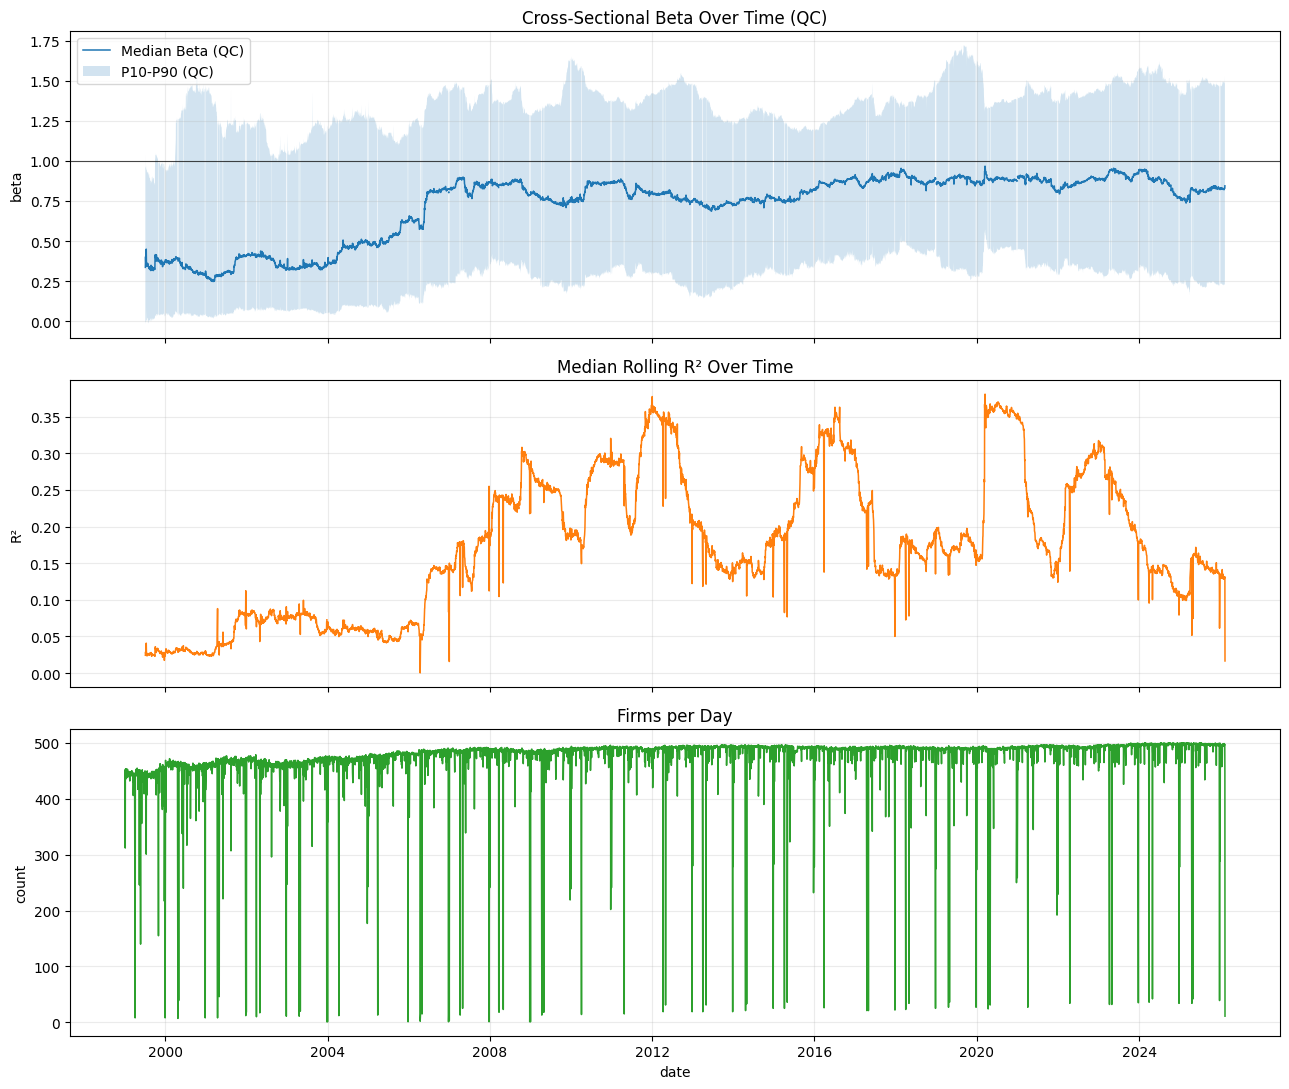

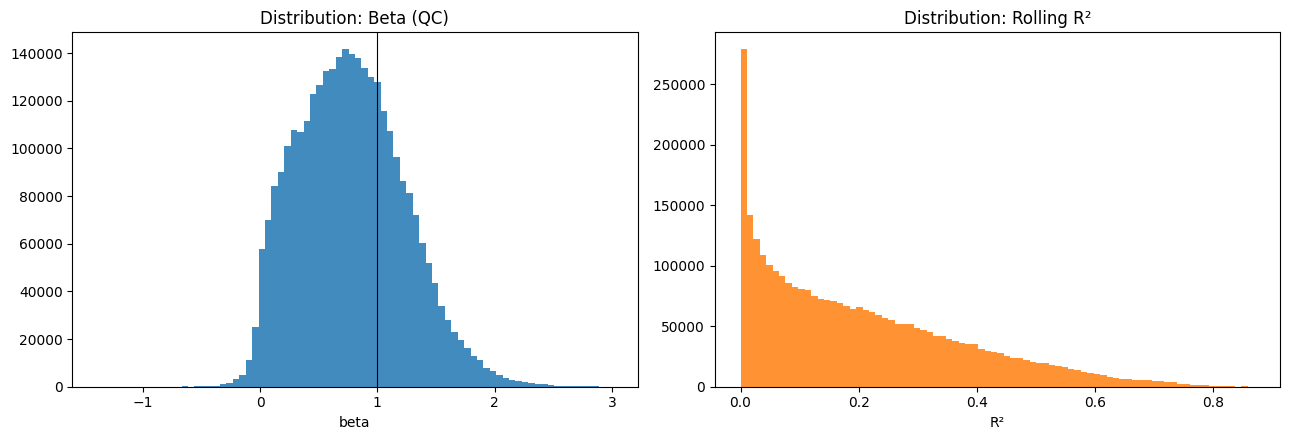

In [15]:
import matplotlib.pyplot as plt

plot_df = analysis_df.dropna(subset=["date"]).copy()

beta_daily_stats = (
    plot_df.groupby("date", as_index=False)
    .agg(
        beta_median=("beta_capm_daily", "median"),
        beta_p10=("beta_capm_daily", lambda s: s.quantile(0.10)),
        beta_p90=("beta_capm_daily", lambda s: s.quantile(0.90)),
        r2_median=("r2_capm_daily", "median"),
        n_firms=("n_firms_day", "max"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(beta_daily_stats["date"], beta_daily_stats["beta_median"], lw=1.1, label="Median Beta (QC)")
axes[0].fill_between(
    beta_daily_stats["date"],
    beta_daily_stats["beta_p10"],
    beta_daily_stats["beta_p90"],
    alpha=0.2,
    label="P10-P90 (QC)",
)
axes[0].axhline(1.0, color="black", lw=0.8, alpha=0.7)
axes[0].set_title("Cross-Sectional Beta Over Time (QC)")
axes[0].set_ylabel("beta")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(beta_daily_stats["date"], beta_daily_stats["r2_median"], color="tab:orange", lw=1.1)
axes[1].set_title("Median Rolling R² Over Time")
axes[1].set_ylabel("R²")
axes[1].grid(alpha=0.25)

axes[2].plot(beta_daily_stats["date"], beta_daily_stats["n_firms"], color="tab:green", lw=1.1)
axes[2].set_title("Firms per Day")
axes[2].set_ylabel("count")
axes[2].set_xlabel("date")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(plot_df["beta_capm_daily"].dropna(), bins=80, color="tab:blue", alpha=0.85)
axes[0].axvline(1.0, color="black", lw=0.8)
axes[0].set_title("Distribution: Beta (QC)")
axes[0].set_xlabel("beta")

axes[1].hist(plot_df["r2_capm_daily"].dropna(), bins=80, color="tab:orange", alpha=0.85)
axes[1].set_title("Distribution: Rolling R²")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()


## 3. EPS Forecasts FY1-FY5 fuer EURO500 laden

Ziel:
- Fuer jeden Eintrag in `euro500` einen As-of EPS-Forecast ziehen
- Horizont `FY1` bis `FY5`
- Ergebnis als `EURO500_EPS.parquet` mit je einer Spalte pro Forecast-Horizont

### Ablauf (robust)
1. Request-Key bauen: `asof_date x pull_ric`
2. Nach Datum gruppiert in Batches ziehen (`BATCH_SIZE`)
3. Pro Batch Checkpoint-Parquet schreiben (auch wenn leer, um Endlosschleifen zu vermeiden)
4. Batch-Fehler via rekursivem Split isolieren und problematische RICs loggen
5. Alle Teile konsolidieren und sauber auf `euro500` zurueck mergen

### Wichtige Schalter
- `FORCE_REFRESH_EPS = True`: ignoriert vorhandene Checkpoints und zieht alles neu
- `FORCE_REFRESH_EPS = False`: nutzt vorhandene Checkpoints (schneller, aber ggf. stale)

### Mapping-Logik für FY1-FY5
LSEG liefert je nach Antwortformat nicht immer explizite FY-Tags im Spaltennamen.
Deshalb wird zweistufig gemappt:
- zuerst ueber Namensmatch (`EPS`, `MEAN`, `FYx`)
- falls nicht eindeutig: Fallback ueber Spaltenreihenfolge nach Instrument

Damit wird verhindert, dass valide EPS-Werte durch uneindeutige Header als `NaN` enden.


In [16]:
# ------------------------------------------------------------
# Step 3 — Robust EPS Forecast Pull (FY1-FY5) with checkpoints
# ------------------------------------------------------------

HORIZONS = ["FY1", "FY2", "FY3", "FY4", "FY5"]
EPS_FIELDS = [f"TR.EPSMean(period={h})" for h in HORIZONS]
BATCH_SIZE = 100
FORCE_REFRESH_EPS = False
MAX_SPLIT_DEPTH = 10

EURO500_EPS_PATH = DATA_DIR / "euro500_x_EPS.parquet"
EPS_CKPT_DIR = DATA_DIR / "eps_checkpoints"
EPS_CKPT_DIR.mkdir(parents=True, exist_ok=True)
EPS_BAD_RICS_LOG = DATA_DIR / "eps_bad_rics.csv"


def _clean_str(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    x = x.where(x.notna() & (x != ""), pd.NA)
    return x


def _asof_from_euro500(df: pd.DataFrame) -> pd.Series:
    if "date" in df.columns:
        return pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    if "formation_date" in df.columns:
        return pd.to_datetime(df["formation_date"], errors="coerce").dt.normalize()
    if "effective_date" in df.columns:
        return pd.to_datetime(df["effective_date"], errors="coerce").dt.normalize()
    raise ValueError("No usable date column found in euro500 (expected date/formation_date/effective_date).")


def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]


def _ckpt_path(asof: pd.Timestamp, batch_ix: int) -> Path:
    return EPS_CKPT_DIR / f"eps_{asof.strftime('%Y%m%d')}_batch_{batch_ix:04d}.parquet"


def _atomic_to_parquet(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_parquet(tmp, index=False)
    tmp.replace(path)


def _append_bad_rics(bad_list: list[str], asof: pd.Timestamp, reason: str):
    if not bad_list:
        return
    d = pd.DataFrame({"pull_ric": bad_list, "asof_date": pd.to_datetime(asof), "reason": reason})
    if EPS_BAD_RICS_LOG.exists():
        old = pd.read_csv(EPS_BAD_RICS_LOG)
        d = pd.concat([old, d], ignore_index=True)
        d = d.drop_duplicates(subset=["pull_ric", "asof_date", "reason"])
    d.to_csv(EPS_BAD_RICS_LOG, index=False)


def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [
            " | ".join([str(v) for v in tup if v is not None]).strip()
            for tup in x.columns
        ]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _fetch_eps_for_batch(
    batch: list[str],
    asof_str: str,
    asof_date: pd.Timestamp,
    max_split_depth: int = 10,
) -> tuple[pd.DataFrame, list[str]]:
    """
    Fetch EPSMean forecasts for a batch.
    On failure, recursively split batch until success or bad single RIC is identified.
    Returns: (raw_df, bad_rics)
    """
    if not batch:
        return pd.DataFrame(), []

    params = {"SDate": asof_str, "EDate": asof_str}

    try:
        raw = ld.get_data(universe=batch, fields=EPS_FIELDS, parameters=params)
        if raw is None or len(raw) == 0:
            return pd.DataFrame(), []
        return pd.DataFrame(raw), []
    except Exception:
        if len(batch) == 1 or max_split_depth <= 0:
            return pd.DataFrame(), [batch[0]]

        mid = len(batch) // 2
        left = batch[:mid]
        right = batch[mid:]

        df_l, bad_l = _fetch_eps_for_batch(left, asof_str, asof_date, max_split_depth=max_split_depth - 1)
        df_r, bad_r = _fetch_eps_for_batch(right, asof_str, asof_date, max_split_depth=max_split_depth - 1)

        out = []
        if df_l is not None and not df_l.empty:
            out.append(df_l)
        if df_r is not None and not df_r.empty:
            out.append(df_r)

        df_out = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
        return df_out, (bad_l + bad_r)


def _standardize_eps_df(df: pd.DataFrame, asof_date: pd.Timestamp) -> pd.DataFrame:
    """
    Standardize get_data result into columns:
    pull_ric, asof_date, EPS_FY1..EPS_FY5

    Robust to:
    - MultiIndex columns
    - duplicate column names
    - column name variants from LSEG
    """
    out_cols = ["pull_ric", "asof_date"] + [f"EPS_{h}" for h in HORIZONS]
    if df is None or getattr(df, "empty", True):
        return pd.DataFrame(columns=out_cols)

    x = _flatten_columns(df)

    # instrument / ric column
    ric_col = None
    for c in x.columns:
        cl = c.lower()
        if cl in {"instrument", "ric"}:
            ric_col = c
            break
    if ric_col is None:
        for c in x.columns:
            cl = c.lower()
            if "instrument" in cl or cl.endswith("ric"):
                ric_col = c
                break
    if ric_col is None:
        ric_col = x.columns[0]

    std = pd.DataFrame({
        "pull_ric": x[ric_col].astype("string").str.strip(),
        "asof_date": pd.to_datetime(asof_date),
    })

    def _as_series(v):
        if isinstance(v, pd.DataFrame):
            return v.iloc[:, 0]
        return v

    # map each horizon by searching column names first.
    # If provider returns duplicate generic headers (e.g. "Earnings Per Share - Mean"
    # repeated 5x without FY tag), fall back to field order after instrument column.
    ric_pos = list(x.columns).index(ric_col)
    value_pos = [i for i in range(len(x.columns)) if i != ric_pos]

    for h_ix, h in enumerate(HORIZONS):
        target = f"EPS_{h}"
        col_match = None

        # Prefer explicit FY-tagged column names when available.
        for c in x.columns:
            uc = c.upper()
            if ("EPS" in uc) and ("MEAN" in uc) and (h in uc):
                col_match = c
                break
        if col_match is None:
            for c in x.columns:
                uc = c.upper()
                if ("EPS" in uc) and (h in uc):
                    col_match = c
                    break

        if col_match is not None:
            s = _as_series(x[col_match])
            std[target] = pd.to_numeric(s, errors="coerce")
            continue

        # Fallback: assign by ordinal field position (FY1..FY5).
        if h_ix < len(value_pos):
            s = x.iloc[:, value_pos[h_ix]]
            std[target] = pd.to_numeric(s, errors="coerce")
        else:
            std[target] = np.nan

    std["pull_ric"] = _clean_str(std["pull_ric"])
    std = std.dropna(subset=["pull_ric"]).drop_duplicates(subset=["pull_ric", "asof_date"], keep="last")

    return std[out_cols]


# ------------------------------------------------------------
# Build request universe from euro500
# ------------------------------------------------------------
euro500_eps = euro500.copy()
euro500_eps["asof_date"] = _asof_from_euro500(euro500_eps)

if "RIC_current" in euro500_eps.columns:
    ric_current = _clean_str(euro500_eps["RIC_current"])
else:
    ric_current = pd.Series(pd.NA, index=euro500_eps.index, dtype="string")

if "RIC" in euro500_eps.columns:
    ric_raw = _clean_str(euro500_eps["RIC"])
else:
    ric_raw = pd.Series(pd.NA, index=euro500_eps.index, dtype="string")

euro500_eps["pull_ric"] = ric_current.fillna(ric_raw)

req = (
    euro500_eps[["asof_date", "pull_ric"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("EPS request rows (unique asof_date x pull_ric):", len(req))
print("As-of date range:", req["asof_date"].min(), "to", req["asof_date"].max())


# ------------------------------------------------------------
# Pull with checkpoints + recursive split
# ------------------------------------------------------------
rows = []

by_date = (
    req.groupby("asof_date", sort=True)["pull_ric"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .reset_index()
)

ld.open_session()
try:
    for d_ix, r in by_date.iterrows():
        asof_date = pd.to_datetime(r["asof_date"])
        asof_str = asof_date.strftime("%Y-%m-%d")
        rics = list(r["pull_ric"])

        print(f"[{d_ix+1}/{len(by_date)}] AsOf {asof_str} | RICs={len(rics)}")

        for b_ix, batch in enumerate(_chunks(rics, BATCH_SIZE), start=1):
            ck = _ckpt_path(asof_date, b_ix)

            if ck.exists() and not FORCE_REFRESH_EPS:
                try:
                    part = pd.read_parquet(ck)
                    rows.append(part)
                    continue
                except Exception:
                    try:
                        ck.unlink()
                    except Exception:
                        pass

            raw_df, bad = _fetch_eps_for_batch(
                batch=batch,
                asof_str=asof_str,
                asof_date=asof_date,
                max_split_depth=MAX_SPLIT_DEPTH,
            )

            if bad:
                _append_bad_rics(bad, asof=asof_date, reason="get_data_failed_recursive_split")

            part = _standardize_eps_df(raw_df, asof_date=asof_date)

            # write checkpoint even if empty to avoid endless retries
            _atomic_to_parquet(part, ck)
            rows.append(part)

finally:
    ld.close_session()


# ------------------------------------------------------------
# Consolidate + merge back to euro500 rows
# ------------------------------------------------------------
out_cols = ["pull_ric", "asof_date"] + [f"EPS_{h}" for h in HORIZONS]
if rows:
    eps_panel = pd.concat(rows, ignore_index=True)
else:
    eps_panel = pd.DataFrame(columns=out_cols)

eps_panel["asof_date"] = pd.to_datetime(eps_panel.get("asof_date"), errors="coerce")
eps_panel = eps_panel[eps_panel["asof_date"].notna()].copy()

eps_panel = (
    eps_panel.sort_values(["pull_ric", "asof_date"])
    .drop_duplicates(["pull_ric", "asof_date"], keep="last")
    .reset_index(drop=True)
)

euro500_eps = euro500_eps.merge(eps_panel, on=["pull_ric", "asof_date"], how="left")

euro500_eps.to_parquet(EURO500_EPS_PATH, index=False)

print("Saved:", EURO500_EPS_PATH)
print("Rows:", len(euro500_eps))
print("Unique pull_ric:", euro500_eps["pull_ric"].nunique(dropna=True))
for h in HORIZONS:
    c = f"EPS_{h}"
    miss = int(euro500_eps[c].isna().sum()) if c in euro500_eps.columns else -1
    print(f"Missing {c}: {miss}")
print(f"[INFO] Bad RIC log (if any): {EPS_BAD_RICS_LOG}")



EPS request rows (unique asof_date x pull_ric): 54000
As-of date range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
[1/108] AsOf 1998-12-31 | RICs=500
[2/108] AsOf 1999-03-31 | RICs=500
[3/108] AsOf 1999-06-30 | RICs=500
[4/108] AsOf 1999-09-30 | RICs=500
[5/108] AsOf 1999-12-31 | RICs=500
[6/108] AsOf 2000-03-31 | RICs=500
[7/108] AsOf 2000-06-30 | RICs=500
[8/108] AsOf 2000-09-29 | RICs=500
[9/108] AsOf 2000-12-29 | RICs=500
[10/108] AsOf 2001-03-30 | RICs=500
[11/108] AsOf 2001-06-29 | RICs=500
[12/108] AsOf 2001-09-28 | RICs=500
[13/108] AsOf 2001-12-31 | RICs=500
[14/108] AsOf 2002-03-29 | RICs=500
[15/108] AsOf 2002-06-28 | RICs=500
[16/108] AsOf 2002-09-30 | RICs=500
[17/108] AsOf 2002-12-31 | RICs=500
[18/108] AsOf 2003-03-31 | RICs=500
[19/108] AsOf 2003-06-30 | RICs=500
[20/108] AsOf 2003-09-30 | RICs=500
[21/108] AsOf 2003-12-31 | RICs=500
[22/108] AsOf 2004-03-31 | RICs=500
[23/108] AsOf 2004-06-30 | RICs=500
[24/108] AsOf 2004-09-30 | RICs=500
[25/108] AsOf 2004-12-31 | RIC

## 4. Long-Term Growth (TR.LTGMean) fuer `euro500_x_EPS` laden

Ziel:
- Fuer jede Request-Kombination `asof_date x pull_ric` den Long-Term-Growth-Mean ziehen
- Feld: `TR.LTGMean`
- Ergebnis als Spalte `LTGMean` in derselben Tabelle `euro500_x_EPS.parquet` speichern

Implementierung:
1. Requests aus `euro500_x_EPS.parquet` bauen (`asof_date`, `pull_ric`)
2. Pull nach Datum in Batches, inkl. Checkpoints
3. Rekursiver Split bei Batch-Fehlern, problematische RICs loggen
4. Merge auf `pull_ric` + `asof_date` und Datei ueberschreiben


In [17]:
# ------------------------------------------------------------
# Step 4 — Robust Long-Term Growth Pull (TR.LTGMean)
# ------------------------------------------------------------

LTG_FIELD = 'TR.LTGMean'
LTG_COL = 'LTGMean'
LTG_BATCH_SIZE = 200
FORCE_REFRESH_LTG = False
MAX_SPLIT_DEPTH_LTG = 10

LTG_CKPT_DIR = DATA_DIR / 'ltg_checkpoints'
LTG_CKPT_DIR.mkdir(parents=True, exist_ok=True)
LTG_BAD_RICS_LOG = DATA_DIR / 'ltg_bad_rics.csv'

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

euro500_eps_ltg = pd.read_parquet(EURO500_EPS_PATH).copy()

if 'asof_date' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['asof_date'] = _asof_from_euro500(euro500_eps_ltg)
else:
    euro500_eps_ltg['asof_date'] = pd.to_datetime(euro500_eps_ltg['asof_date'], errors='coerce').dt.normalize()

if 'pull_ric' not in euro500_eps_ltg.columns:
    ric_current = _clean_str(euro500_eps_ltg['RIC_current']) if 'RIC_current' in euro500_eps_ltg.columns else pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string')
    ric_raw = _clean_str(euro500_eps_ltg['RIC']) if 'RIC' in euro500_eps_ltg.columns else pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string')
    euro500_eps_ltg['pull_ric'] = ric_current.fillna(ric_raw)
else:
    euro500_eps_ltg['pull_ric'] = _clean_str(euro500_eps_ltg['pull_ric'])

req_ltg = (
    euro500_eps_ltg[['asof_date', 'pull_ric']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print('LTG request rows (unique asof_date x pull_ric):', len(req_ltg))
print('As-of date range:', req_ltg['asof_date'].min(), 'to', req_ltg['asof_date'].max())


def _ltg_ckpt_path(asof: pd.Timestamp, batch_ix: int) -> Path:
    return LTG_CKPT_DIR / f"ltg_{asof.strftime('%Y%m%d')}_batch_{batch_ix:04d}.parquet"


def _append_bad_rics_ltg(bad_list: list[str], asof: pd.Timestamp, reason: str):
    if not bad_list:
        return
    d = pd.DataFrame({'pull_ric': bad_list, 'asof_date': pd.to_datetime(asof), 'reason': reason})
    if LTG_BAD_RICS_LOG.exists():
        old = pd.read_csv(LTG_BAD_RICS_LOG)
        d = pd.concat([old, d], ignore_index=True)
        d = d.drop_duplicates(subset=['pull_ric', 'asof_date', 'reason'])
    d.to_csv(LTG_BAD_RICS_LOG, index=False)


def _fetch_ltg_for_batch(batch: list[str], asof_str: str, max_split_depth: int = 10) -> tuple[pd.DataFrame, list[str]]:
    if not batch:
        return pd.DataFrame(), []

    params = {'SDate': asof_str, 'EDate': asof_str}

    try:
        raw = ld.get_data(universe=batch, fields=[LTG_FIELD], parameters=params)
        if raw is None or len(raw) == 0:
            return pd.DataFrame(), []
        return pd.DataFrame(raw), []
    except Exception:
        if len(batch) == 1 or max_split_depth <= 0:
            return pd.DataFrame(), [batch[0]]

        mid = len(batch) // 2
        left = batch[:mid]
        right = batch[mid:]

        df_l, bad_l = _fetch_ltg_for_batch(left, asof_str, max_split_depth=max_split_depth - 1)
        df_r, bad_r = _fetch_ltg_for_batch(right, asof_str, max_split_depth=max_split_depth - 1)

        out = []
        if df_l is not None and not df_l.empty:
            out.append(df_l)
        if df_r is not None and not df_r.empty:
            out.append(df_r)

        df_out = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
        return df_out, (bad_l + bad_r)


def _standardize_ltg_df(df: pd.DataFrame, asof_date: pd.Timestamp) -> pd.DataFrame:
    out_cols = ['pull_ric', 'asof_date', LTG_COL]
    if df is None or getattr(df, 'empty', True):
        return pd.DataFrame(columns=out_cols)

    x = _flatten_columns(df)

    ric_col = None
    for c in x.columns:
        cl = c.lower()
        if cl in {'instrument', 'ric'}:
            ric_col = c
            break
    if ric_col is None:
        for c in x.columns:
            cl = c.lower()
            if 'instrument' in cl or cl.endswith('ric'):
                ric_col = c
                break
    if ric_col is None:
        ric_col = x.columns[0]

    ltg_col = None
    for c in x.columns:
        uc = c.upper()
        if 'LTG' in uc or 'LONG' in uc or 'TR.LTGMEAN' in uc:
            if c != ric_col:
                ltg_col = c
                break

    if ltg_col is None:
        value_cols = [c for c in x.columns if c != ric_col]
        if not value_cols:
            return pd.DataFrame(columns=out_cols)
        ltg_col = value_cols[0]

    out = pd.DataFrame({
        'pull_ric': _clean_str(x[ric_col]),
        'asof_date': pd.to_datetime(asof_date),
        LTG_COL: pd.to_numeric(x[ltg_col], errors='coerce'),
    })

    out = out.dropna(subset=['pull_ric']).drop_duplicates(['pull_ric', 'asof_date'], keep='last')
    return out[out_cols]


rows_ltg = []
by_date_ltg = (
    req_ltg.groupby('asof_date', sort=True)['pull_ric']
    .apply(lambda s: sorted(set(s.astype(str))))
    .reset_index()
)

ld.open_session()
try:
    for d_ix, r in by_date_ltg.iterrows():
        asof_date = pd.to_datetime(r['asof_date'])
        asof_str = asof_date.strftime('%Y-%m-%d')
        rics = list(r['pull_ric'])

        print(f'[{d_ix+1}/{len(by_date_ltg)}] AsOf {asof_str} | RICs={len(rics)}')

        for b_ix, batch in enumerate(_chunks(rics, LTG_BATCH_SIZE), start=1):
            ck = _ltg_ckpt_path(asof_date, b_ix)

            if ck.exists() and not FORCE_REFRESH_LTG:
                try:
                    part = pd.read_parquet(ck)
                    rows_ltg.append(part)
                    continue
                except Exception:
                    try:
                        ck.unlink()
                    except Exception:
                        pass

            raw_df, bad = _fetch_ltg_for_batch(batch=batch, asof_str=asof_str, max_split_depth=MAX_SPLIT_DEPTH_LTG)

            if bad:
                _append_bad_rics_ltg(bad, asof=asof_date, reason='get_data_failed_recursive_split')

            part = _standardize_ltg_df(raw_df, asof_date=asof_date)
            _atomic_to_parquet(part, ck)
            rows_ltg.append(part)
finally:
    ld.close_session()


if rows_ltg:
    ltg_panel = pd.concat(rows_ltg, ignore_index=True)
else:
    ltg_panel = pd.DataFrame(columns=['pull_ric', 'asof_date', LTG_COL])

ltg_panel['asof_date'] = pd.to_datetime(ltg_panel.get('asof_date'), errors='coerce')
ltg_panel = ltg_panel[ltg_panel['asof_date'].notna()].copy()
ltg_panel = (
    ltg_panel.sort_values(['pull_ric', 'asof_date'])
    .drop_duplicates(['pull_ric', 'asof_date'], keep='last')
    .reset_index(drop=True)
)

if LTG_COL in euro500_eps_ltg.columns:
    euro500_eps_ltg = euro500_eps_ltg.drop(columns=[LTG_COL])

euro500_eps_ltg = euro500_eps_ltg.merge(ltg_panel, on=['pull_ric', 'asof_date'], how='left')
euro500_eps_ltg.to_parquet(EURO500_EPS_PATH, index=False)

print('Saved:', EURO500_EPS_PATH)
print('Rows:', len(euro500_eps_ltg))
print('Missing LTGMean:', int(euro500_eps_ltg[LTG_COL].isna().sum()))
print(f'[INFO] LTG bad RIC log (if any): {LTG_BAD_RICS_LOG}')


LTG request rows (unique asof_date x pull_ric): 54000
As-of date range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
[1/108] AsOf 1998-12-31 | RICs=500
[2/108] AsOf 1999-03-31 | RICs=500
[3/108] AsOf 1999-06-30 | RICs=500
[4/108] AsOf 1999-09-30 | RICs=500
[5/108] AsOf 1999-12-31 | RICs=500
[6/108] AsOf 2000-03-31 | RICs=500
[7/108] AsOf 2000-06-30 | RICs=500
[8/108] AsOf 2000-09-29 | RICs=500
[9/108] AsOf 2000-12-29 | RICs=500
[10/108] AsOf 2001-03-30 | RICs=500
[11/108] AsOf 2001-06-29 | RICs=500
[12/108] AsOf 2001-09-28 | RICs=500
[13/108] AsOf 2001-12-31 | RICs=500
[14/108] AsOf 2002-03-29 | RICs=500
[15/108] AsOf 2002-06-28 | RICs=500
[16/108] AsOf 2002-09-30 | RICs=500
[17/108] AsOf 2002-12-31 | RICs=500
[18/108] AsOf 2003-03-31 | RICs=500
[19/108] AsOf 2003-06-30 | RICs=500
[20/108] AsOf 2003-09-30 | RICs=500
[21/108] AsOf 2003-12-31 | RICs=500
[22/108] AsOf 2004-03-31 | RICs=500
[23/108] AsOf 2004-06-30 | RICs=500
[24/108] AsOf 2004-09-30 | RICs=500
[25/108] AsOf 2004-12-31 | RIC

## 4B. LTG Analyse (Qualitaet und Plausibilitaet)

Diese Sektion analysiert die neu gezogene Spalte `LTGMean` in `euro500_x_EPS.parquet`.

Checks:
- Abdeckung (overall + über Zeit)
- Verteilung (raw und winsorized)
- Plausibilitaets-Baender (z. B. LTG < -100% oder > 100%)
- Querschnitt nach Sektor und Land


,rows_total,ltg_non_null,ltg_missing,coverage_share,ltg_lt_-1_count,ltg_gt_+1_count
0,54000,31305,22695,0.579722,2490,27831


LTGMean describe (raw):


count      31305.0
mean     12.596678
std      18.438652
min         -212.0
1%           -21.8
5%         -4.7256
25%            5.0
50%           10.0
75%          16.25
95%         38.125
99%        78.9464
max         612.87
Name: LTGMean, dtype: Float64

LTGMean describe (winsorized 1%-99%):


count      31305.0
mean     12.379419
std      14.397882
min          -21.8
1%           -21.8
5%         -4.7256
25%            5.0
50%           10.0
75%          16.25
95%         38.125
99%      78.942944
max        78.9464
Name: LTGMean, dtype: Float64

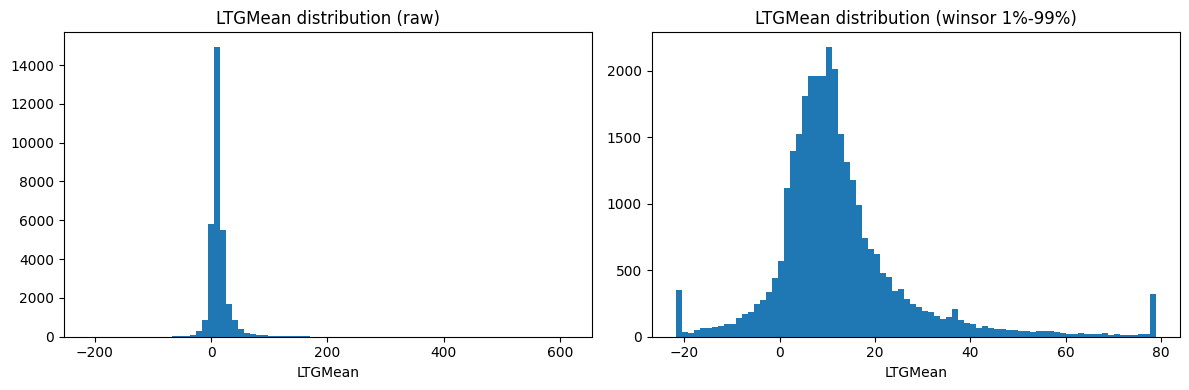

,year,rows,non_null,median,p10,p90,coverage
0,1998,500,180.0,12.5,4.318197,21.175,0.36
1,1999,2000,874.0,12.905,4.7,25.0,0.437
2,2000,2000,881.0,15.0,4.8,35.5,0.4405
3,2001,2000,980.0,15.0,5.0,34.1439,0.49
4,2002,2000,1088.0,11.84,3.2,28.4825,0.544
5,2003,2000,1152.0,10.84615,2.87025,25.0,0.576
6,2004,2000,1093.0,10.57,3.33333,24.652,0.5465
7,2005,2000,909.0,9.39,2.69,25.0,0.4545
8,2006,2000,1028.0,8.955,2.5,22.6285,0.514
9,2007,2000,1147.0,9.26667,2.25,22.683,0.5735


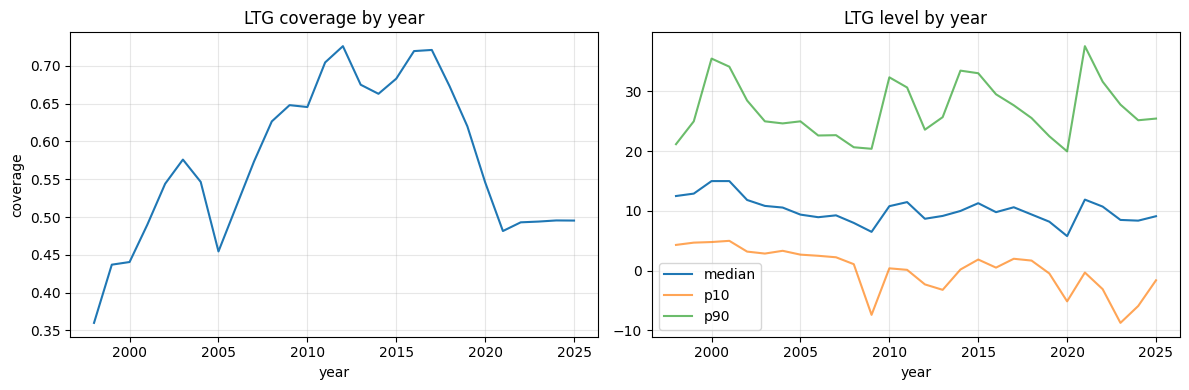

By trbc_sector:


,trbc_sector,n,non_null,median,mean,coverage
9,Technology,7185,4719.0,11.0,12.844128,0.656785
5,Healthcare,4880,3022.0,11.2,13.060281,0.619262
6,Industrials,11394,6961.0,10.77,13.782319,0.610936
4,Energy,2607,1576.0,6.8,11.07424,0.604526
2,Consumer Cyclicals,9851,5823.0,11.0,14.932023,0.591108
1,Basic Materials,6225,3603.0,9.8775,12.841735,0.578795
3,Consumer Non-Cyclicals,4667,2608.0,9.218275,10.37225,0.558817
10,Utilities,3186,1762.0,5.7,6.409531,0.553045
8,Real Estate,3971,1227.0,5.5,7.512578,0.30899
7,"Institutions, Associations & Organizations",29,4.0,6.0,21.8425,0.137931


By hq_country:


,hq_country,n,non_null,median,mean,coverage
6,France,12914,8616.0,10.1875,12.871972,0.667183
7,Germany,11351,7381.0,10.525,13.236087,0.650251
14,Netherlands,3719,2366.0,10.47738,13.720798,0.636193
9,Ireland,2500,1553.0,11.64,13.258236,0.6212
5,Finland,3262,1919.0,6.0,9.098091,0.588289
18,Spain,4658,2511.0,10.0,12.166382,0.539073
0,Austria,2260,1196.0,8.03,11.390551,0.529204
15,Portugal,1287,617.0,10.0,12.422609,0.479409
10,Italy,5172,2408.0,9.61875,14.496061,0.465584
12,Luxembourg,1304,606.0,12.331665,14.915816,0.464724


In [18]:
import matplotlib.pyplot as plt

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

ltg_df = pd.read_parquet(EURO500_EPS_PATH).copy()
if 'LTGMean' not in ltg_df.columns:
    raise KeyError('Column LTGMean not found. Run Step 4 first.')

# Datentypen / Datumsfelder
for dc in ['asof_date', 'date', 'formation_date', 'effective_date']:
    if dc in ltg_df.columns:
        ltg_df[dc] = pd.to_datetime(ltg_df[dc], errors='coerce')

ltg_df['LTGMean'] = pd.to_numeric(ltg_df['LTGMean'], errors='coerce')

if 'asof_date' in ltg_df.columns and ltg_df['asof_date'].notna().any():
    ltg_df['year'] = ltg_df['asof_date'].dt.year
elif 'date' in ltg_df.columns:
    ltg_df['year'] = ltg_df['date'].dt.year
else:
    ltg_df['year'] = pd.NA

# 1) Overall coverage + basic stats
n_total = len(ltg_df)
n_non_null = int(ltg_df['LTGMean'].notna().sum())
n_missing = n_total - n_non_null
coverage = (n_non_null / n_total) if n_total else np.nan

outlier_lo = (ltg_df['LTGMean'] < -1).sum()
outlier_hi = (ltg_df['LTGMean'] > 1).sum()

summary = pd.DataFrame([{
    'rows_total': n_total,
    'ltg_non_null': n_non_null,
    'ltg_missing': n_missing,
    'coverage_share': coverage,
    'ltg_lt_-1_count': int(outlier_lo),
    'ltg_gt_+1_count': int(outlier_hi),
}])
display(summary)

ltg_ok = ltg_df['LTGMean'].dropna()
if len(ltg_ok) > 0:
    print('LTGMean describe (raw):')
    display(ltg_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    p01, p99 = ltg_ok.quantile([0.01, 0.99])
    ltg_w = ltg_ok.clip(lower=p01, upper=p99)
    print('LTGMean describe (winsorized 1%-99%):')
    display(ltg_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(ltg_ok, bins=80)
    ax[0].set_title('LTGMean distribution (raw)')
    ax[0].set_xlabel('LTGMean')

    ax[1].hist(ltg_w, bins=80)
    ax[1].set_title('LTGMean distribution (winsor 1%-99%)')
    ax[1].set_xlabel('LTGMean')
    plt.tight_layout()
    plt.show()
else:
    print('No non-null LTGMean values found.')

# 2) Coverage over time
if 'year' in ltg_df.columns and ltg_df['year'].notna().any():
    cov_year = ltg_df.groupby('year', as_index=False).agg(
        rows=('LTGMean', 'size'),
        non_null=('LTGMean', lambda s: s.notna().sum()),
        median=('LTGMean', 'median'),
        p10=('LTGMean', lambda s: s.quantile(0.10)),
        p90=('LTGMean', lambda s: s.quantile(0.90)),
    )
    cov_year['coverage'] = cov_year['non_null'] / cov_year['rows']
    display(cov_year.head(20))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(cov_year['year'], cov_year['coverage'])
    ax[0].set_title('LTG coverage by year')
    ax[0].set_xlabel('year')
    ax[0].set_ylabel('coverage')
    ax[0].grid(alpha=0.3)

    ax[1].plot(cov_year['year'], cov_year['median'], label='median')
    ax[1].plot(cov_year['year'], cov_year['p10'], label='p10', alpha=0.7)
    ax[1].plot(cov_year['year'], cov_year['p90'], label='p90', alpha=0.7)
    ax[1].set_title('LTG level by year')
    ax[1].set_xlabel('year')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3) Cross-section by sector / country
for grp_col in ['trbc_sector', 'hq_country']:
    if grp_col in ltg_df.columns:
        g = (
            ltg_df.groupby(grp_col, dropna=False)['LTGMean']
            .agg(n='size', non_null=lambda s: s.notna().sum(), median='median', mean='mean')
            .reset_index()
        )
        g['coverage'] = g['non_null'] / g['n']
        g = g.sort_values(['coverage', 'n'], ascending=[False, False])
        print(f'By {grp_col}:')
        display(g.head(20))


## 5. Net-Payout Items fuer `euro500` laden (vollstaendige Pipeline)

Ziel:
- Pro `pull_ric x asof_date` moeglichst vollstaendige Fundamentals fuer die Duration-Berechnung erzeugen.
- Ergebnis in `euro500_netpayout.parquet` speichern, inklusive duration-ready Zusatzspalten.

### Zielvariablen
- `BE` (`TR.F.ComEqTot`)
- `assets` (`TR.F.TotAssets`)
- `sales` (`TR.F.TotRevenue`)
- `net_income` (`TR.F.NetIncAfterTax`)
- `gross_profit` (`TR.GrossIncomeActValue` + Fallback-Logik)
- `debt` (`TR.F.DebtTot`)
- `dividends` (`TR.F.DivPaidCashTotCF`)
- `buybacks` (`TR.F.ComStockBuybackNet`)

### Pull-Logik (mehrstufig)
1. Request-Grid aus `euro500` bauen: `asof_date x pull_ric`.
2. Primaerer Panel-Pull mit `FRQ="Q"` ueber den gesamten Zeitraum.
3. Optionaler Fallback-Pull mit `FRQ="Y"`.
4. As-of-Merge (`<= asof_date`) auf das Request-Grid.
5. Optionaler Forward-As-of-Fill (Toleranz in Tagen), um Reporting-Versatz zu reduzieren.

### Robustheit / Stabilitaet
- Batch-Pulls mit Checkpoints.
- Retry + Timeout je Request.
- Session-Recovery bei Transportfehlern.
- Rekursiver Split bei Batch-Fehlern zur Isolierung problematischer RICs.
- Fehler-RICs werden in `netpayout_bad_rics.csv` geloggt.

### Zusatze Fallbacks fuer Coverage
- `gross_profit`-Spezialfallback:
  - Hilfsfelder (`GrossMargPct`, `CostOfRevenue`) fuer konstruiertes Gross Profit.
  - zusaetzlicher Snapshot-Backfill (`SDate=EDate=asof`) fuer verbleibende Luecken.
- Optionaler All-Fields-Snapshot-Backfill:
  - zieht bei verbleibenden Luecken alle Zielvariablen als As-of-Snapshot nach.

### Duration-ready Output (direkt fuer nachgelagerte Rechnung)
Neben den Level-Spalten werden erzeugt:
- `obs_date`, `obs_age_days`, `duration_data_regime`
- Flow-TTM-Spalten: `sales_ttm`, `net_income_ttm`, `gross_profit_ttm`, `dividends_ttm`, `buybacks_ttm`
- `PO_ttm = dividends_ttm + buybacks_ttm`
- Quellenflags je Flow: `*_ttm_source` (`Q_TTM` oder `A_LEVEL`)
- `duration_q_share` (Anteil Q-basierter Flows je Zeile)

### Caching-Verhalten
- `FORCE_REFRESH_NET=False`: nutzt vorhandene Checkpoints (schnell).
- Leere/defekte Checkpoints werden automatisch invalidiert und neu gezogen.
- `FORCE_REFRESH_NET=True`: kompletter Neuaufbau.



In [19]:
# ------------------------------------------------------------
# Step 5 - Net-Payout Pull (clean quarterly vs annual mapping)
#   Design (as agreed):
#   - Quarterly (FQ) items pulled quarterly, then TTM: sales, net_income, gross_profit
#   - Annual (FY) items pulled annual, mapped to ALL quarters in year X+1:
#       BE, assets, debt, dividends, buybacks
# ------------------------------------------------------------

from pathlib import Path
import time, random
import numpy as np
import pandas as pd
import lseg.data as ld
from lseg.data.errors import LDError

# =========================
# 0) CONFIG
# =========================

NET_FIELDS = [
    ("TR.F.ComEqTot", "BE"),
    ("TR.F.TotAssets", "assets"),
    ("TR.F.TotRevenue", "sales"),
    ("TR.F.NetIncAfterTax", "net_income"),
    ("TR.GrossIncomeActValue", "gross_profit"),
    ("TR.F.DebtTot", "debt"),
    ("TR.F.DivPaidCashTotCF", "dividends"),
    ("TR.F.ComStockBuybackNet", "buybacks"),
]

# Quarterly items -> explicit Period=FQ0
NET_QUARTERLY_ITEMS = ["sales", "net_income", "gross_profit"]
NET_FIELD_BY_TARGET_FQ = {
    "sales": "TR.F.TotRevenue(Period=FQ0)",
    "net_income": "TR.F.NetIncAfterTax(Period=FQ0)",
    "gross_profit": "TR.GrossIncomeActValue(Period=FQ0)",
}

# Annual items -> explicit Period=FY0, mapped to year X+1
NET_ANNUAL_ITEMS = ["BE", "assets", "debt", "dividends", "buybacks"]
NET_FIELD_BY_TARGET_FY = {
    "BE": "TR.F.ComEqTot(Period=FY0)",
    "assets": "TR.F.TotAssets(Period=FY0)",
    "debt": "TR.F.DebtTot(Period=FY0)",
    "dividends": "TR.F.DivPaidCashTotCF(Period=FY0)",
    "buybacks": "TR.F.ComStockBuybackNet(Period=FY0)",
}

# Force explicit period-end dates to avoid synthetic/inferred date drift
NET_DATE_FIELD_BY_FRQ = {
    "FQ": "TR.F.PeriodEndDate(Period=FQ0)",
    "FY": "TR.F.PeriodEndDate(Period=FY0)",
}

NET_GROSSPROFIT_FY_FIELD = "TR.GrossIncomeActValue(Period=FY0)"

NET_BATCH_SIZE = 80               # keep small to reduce rate-limit risk
NET_PROGRESS = True
FORCE_REFRESH_NET = True

NET_REQUEST_MAX_RETRIES = 6
NET_RETRY_BASE_SLEEP = 0.8

EURO500_NETPAYOUT_PATH = DATA_DIR / "euro500_netpayout.parquet"
NET_CKPT_DIR = DATA_DIR / "netpayout_checkpoints"
NET_CKPT_DIR.mkdir(parents=True, exist_ok=True)
NET_BAD_RICS_LOG = DATA_DIR / "netpayout_bad_rics.csv"


# =========================
# 1) SMALL HELPERS (self-contained)
# =========================

def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def _clean_str(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip().replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

def _atomic_to_parquet(df: pd.DataFrame, path: Path):
    tmp = path.with_suffix(".tmp.parquet")
    df.to_parquet(tmp, index=False)
    tmp.replace(path)

def _append_bad_rics_net(bad_list: list[str], asof: pd.Timestamp, reason: str):
    if not bad_list:
        return
    d = pd.DataFrame({"pull_ric": bad_list, "asof_date": pd.to_datetime(asof), "reason": reason})
    if NET_BAD_RICS_LOG.exists():
        old = pd.read_csv(NET_BAD_RICS_LOG)
        d = pd.concat([old, d], ignore_index=True).drop_duplicates(subset=["pull_ric", "asof_date", "reason"])
    d.to_csv(NET_BAD_RICS_LOG, index=False)

def _parse_ld_number(x):
    """Handle strings like '1,234', '(123)', '<NA>'."""
    if x is None or pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in {"<NA>", "NA", "N/A", ""}:
        return np.nan
    paren_neg = s.startswith("(") and s.endswith(")")
    s = s.replace(",", "").replace("(", "").replace(")", "")
    v = pd.to_numeric(s, errors="coerce")
    if pd.isna(v):
        return np.nan
    return -v if paren_neg else v

def _is_rate_limit(exc: Exception) -> bool:
    msg = str(exc).lower()
    return ("too many requests" in msg) or ("rate" in msg and "limit" in msg)

def _expected_obs_dates(start_str: str, end_str: str, frq: str) -> list[pd.Timestamp]:
    start = pd.to_datetime(start_str, errors="coerce")
    end = pd.to_datetime(end_str, errors="coerce")
    if pd.isna(start) or pd.isna(end) or start > end:
        return []
    f = str(frq).upper().strip()
    if f == "FQ":
        dates = pd.period_range(start=start, end=end, freq="Q").to_timestamp(how="end")
    elif f == "FY":
        dates = pd.period_range(start=start, end=end, freq="Y").to_timestamp(how="end")
    else:
        dates = pd.date_range(start=start, end=end, freq="D")
    return [pd.Timestamp(d).normalize() for d in dates]

def _detect_ric_col(df: pd.DataFrame) -> str:
    if "Instrument" in df.columns:
        return "Instrument"
    if "RIC" in df.columns:
        return "RIC"
    return df.columns[0]

def _detect_date_col(df: pd.DataFrame) -> str | None:
    cols = list(df.columns)
    low = {c: str(c).lower() for c in cols}

    # Prefer true fundamental period markers
    for key in ["period end date", "fiscal period end date", "periodenddate"]:
        for c in cols:
            if key in low[c]:
                return c

    # Fallback: generic date-like column (exclude update/meta dates)
    for c in cols:
        cl = low[c]
        if "date" in cl and "update" not in cl and "calc" not in cl:
            return c
    return None

def _get_data_retry(universe: list[str], fields: list[str], params: dict) -> pd.DataFrame:
    last_exc = None
    for attempt in range(NET_REQUEST_MAX_RETRIES + 1):
        try:
            raw = ld.get_data(universe=universe, fields=fields, parameters=params)
            return pd.DataFrame(raw) if raw is not None else pd.DataFrame()
        except Exception as exc:
            last_exc = exc
            if attempt >= NET_REQUEST_MAX_RETRIES:
                raise
            # backoff, larger if rate limit
            sleep_s = (NET_RETRY_BASE_SLEEP * (2 ** attempt)) + random.random()
            if _is_rate_limit(exc):
                sleep_s *= 2.0
            time.sleep(sleep_s)
    raise last_exc  # pragma: no cover

def _standardize_panel(df_raw: pd.DataFrame, targets: list[str], field_by_target: dict[str, str],
                       expected_dates: list[pd.Timestamp]) -> pd.DataFrame:
    out_cols = ["pull_ric", "obs_date"] + targets
    if df_raw is None or df_raw.empty:
        return pd.DataFrame(columns=out_cols)

    df = df_raw.copy()
    ric_col = _detect_ric_col(df)
    date_col = _detect_date_col(df)

    out = pd.DataFrame({"pull_ric": _clean_str(df[ric_col])})

    if date_col is not None:
        out["obs_date"] = pd.to_datetime(df[date_col], errors="coerce").dt.normalize()
    else:
        out["obs_date"] = pd.NaT

    # Do NOT infer synthetic dates from row position (this can misalign periods badly).
    # If a provider response has no usable date column, rows are dropped below.

    header_patterns = {
        "BE": ["COMMON EQUITY - TOTAL", "TR.F.COMEQTOT", "COMEQTOT"],
        "assets": ["TOTAL ASSETS", "TR.F.TOTASSETS", "TOTASSETS"],
        "sales": ["REVENUE FROM BUSINESS ACTIVITIES - TOTAL", "TOTAL REVENUE", "TR.F.TOTREVENUE", "TOTREVENUE"],
        "net_income": ["NET INCOME AFTER TAX", "TR.F.NETINCAFTERTAX", "NETINCAFTERTAX"],
        "gross_profit": ["GROSS INCOME - ACTUAL", "TR.GROSSINCOMEACTVALUE", "GROSSINCOMEACTVALUE", "TR.F.GROSSPROFIT", "GROSS PROFIT"],
        "debt": ["DEBT - TOTAL", "TR.F.DEBTTOT", "DEBTTOT"],
        "dividends": ["DIVIDENDS PAID - CASH - TOTAL - CASH FLOW", "TR.F.DIVPAIDCASHTOTCF", "DIVPAIDCASHTOTCF"],
        "buybacks": ["COMMON STOCK BUYBACK - NET", "TR.F.COMSTOCKBUYBACKNET", "COMSTOCKBUYBACKNET", "BUYBACK"],
    }

    # Non-RIC/non-date columns for order fallback
    value_cols = [c for c in df.columns if c not in {ric_col, date_col}]

    for idx, t in enumerate(targets):
        col = None

        # 1) exact/embedded field-code match
        code = field_by_target[t]
        codeU = code.upper()
        code_base = code.split("(", 1)[0].upper()
        col = next((c for c in df.columns if str(c).upper() == codeU), None)
        if col is None:
            col = next((c for c in df.columns if codeU in str(c).upper()), None)
        if col is None:
            col = next((c for c in df.columns if code_base in str(c).upper()), None)

        # 2) header pattern match
        if col is None:
            pats = header_patterns.get(t, [])
            col = next((c for c in df.columns if any(p in str(c).upper() for p in pats)), None)

        # 3) fallback by position among value columns
        if col is None and idx < len(value_cols):
            col = value_cols[idx]

        out[t] = df[col].apply(_parse_ld_number) if col is not None else np.nan

    out = out.dropna(subset=["pull_ric", "obs_date"]).copy()
    out = out.sort_values(["pull_ric", "obs_date"]).drop_duplicates(["pull_ric", "obs_date"], keep="last")
    return out[out_cols]

def _panel_ckpt_path(prefix: str, batch_ix: int) -> Path:
    return NET_CKPT_DIR / f"{prefix}_batch_{batch_ix:04d}.parquet"

def _pull_panel(unique_rics: list[str], start_str: str, end_str: str, frq: str,
                targets: list[str], field_by_target: dict[str, str], ckpt_prefix: str,
                date_field_expr: str | None = None) -> pd.DataFrame:
    fields = [field_by_target[t] for t in targets]
    if date_field_expr:
        fields = [date_field_expr] + fields
    expected_dates = _expected_obs_dates(start_str, end_str, frq)

    total_batches = int(np.ceil(len(unique_rics) / NET_BATCH_SIZE)) if unique_rics else 0
    if NET_PROGRESS:
        print(f"[PULL {ckpt_prefix}] start | FRQ={frq} | batches={total_batches} | {start_str}..{end_str}")

    rows = []
    for b_ix, batch in enumerate(_chunks(unique_rics, NET_BATCH_SIZE), start=1):
        ck = _panel_ckpt_path(ckpt_prefix, b_ix)

        if ck.exists() and not FORCE_REFRESH_NET:
            part = pd.read_parquet(ck)
            rows.append(part)
            if NET_PROGRESS:
                print(f"[PULL {ckpt_prefix}] {b_ix}/{total_batches} checkpoint rows={len(part)}")
            continue

        params = {"SDate": start_str, "EDate": end_str, "FRQ": frq}
        bad = []
        try:
            df_raw = _get_data_retry(batch, fields, params)
        except Exception as exc:
            # mark whole batch as bad (keep moving)
            bad = list(batch)
            df_raw = pd.DataFrame()
            if NET_PROGRESS:
                print(f"[PULL {ckpt_prefix}] {b_ix}/{total_batches} ERROR -> marking bad={len(bad)} | {type(exc).__name__}: {exc}")

        if bad:
            _append_bad_rics_net(bad, asof=pd.Timestamp(end_str), reason=f"pull_failed_{ckpt_prefix}")

        part = _standardize_panel(df_raw, targets=targets, field_by_target=field_by_target, expected_dates=expected_dates)
        _atomic_to_parquet(part, ck)
        rows.append(part)

        if NET_PROGRESS:
            print(f"[PULL {ckpt_prefix}] {b_ix}/{total_batches} rows={len(part)} bad={len(bad)}")

    panel_cols = ["pull_ric", "obs_date"] + targets
    panel = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=panel_cols)
    panel["obs_date"] = pd.to_datetime(panel["obs_date"], errors="coerce").dt.normalize()
    panel = panel.dropna(subset=["pull_ric", "obs_date"]).sort_values(["pull_ric", "obs_date"])
    panel = panel.drop_duplicates(["pull_ric", "obs_date"], keep="last")

    if NET_PROGRESS:
        print(f"[PULL {ckpt_prefix}] done | rows={len(panel)}")
    return panel


# =========================
# 2) BUILD REQUEST GRID (from euro500 quarter panel)
# =========================

euro500_net = euro500.copy()
euro500_net["asof_date"] = _asof_from_euro500(euro500_net)  # assumes your existing helper
euro500_net["asof_date"] = pd.to_datetime(euro500_net["asof_date"], errors="coerce").dt.normalize()

ric_current = _clean_str(euro500_net["RIC_current"]) if "RIC_current" in euro500_net.columns else pd.Series(pd.NA, index=euro500_net.index, dtype="string")
ric_raw     = _clean_str(euro500_net["RIC"])         if "RIC" in euro500_net.columns else pd.Series(pd.NA, index=euro500_net.index, dtype="string")
euro500_net["pull_ric"] = ric_current.fillna(ric_raw)

req_net = (
    euro500_net[["asof_date", "pull_ric"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("NetPayout request rows (unique asof_date x pull_ric):", len(req_net))
print("As-of date range:", req_net["asof_date"].min(), "to", req_net["asof_date"].max())

unique_rics = sorted(set(req_net["pull_ric"].astype(str)))
start_str = pd.to_datetime(req_net["asof_date"].min()).strftime("%Y-%m-%d")
end_str   = pd.to_datetime(req_net["asof_date"].max()).strftime("%Y-%m-%d")
print(f"Pull range: {start_str} -> {end_str} | Unique RICs={len(unique_rics)}")

# =========================
# 3) PULL PANELS
# =========================

ld.open_session()
try:
    # Quarterly panel (FQ) for operating flows -> later TTM
    panel_fq = _pull_panel(
        unique_rics=unique_rics,
        start_str=start_str,
        end_str=end_str,
        frq="FQ",
        targets=NET_QUARTERLY_ITEMS,
        field_by_target=NET_FIELD_BY_TARGET_FQ,
        ckpt_prefix="net_fq_ops",
        date_field_expr=NET_DATE_FIELD_BY_FRQ["FQ"],
    )

    # Annual panel (FY) for balance sheet + payouts -> mapped to year+1 quarters
    panel_fy = _pull_panel(
        unique_rics=unique_rics,
        start_str=start_str,
        end_str=end_str,
        frq="FY",
        targets=NET_ANNUAL_ITEMS,
        field_by_target=NET_FIELD_BY_TARGET_FY,
        ckpt_prefix="net_fy_state",
        date_field_expr=NET_DATE_FIELD_BY_FRQ["FY"],
    )

    # Annual gross profit fallback (FY0), mapped to year+1 then scaled to quarter proxy (FY/4)
    panel_gp_fy = _pull_panel(
        unique_rics=unique_rics,
        start_str=start_str,
        end_str=end_str,
        frq="FY",
        targets=["gross_profit"],
        field_by_target={"gross_profit": NET_GROSSPROFIT_FY_FIELD},
        ckpt_prefix="net_fy_grossprofit",
        date_field_expr=NET_DATE_FIELD_BY_FRQ["FY"],
    )

finally:
    ld.close_session()


# =========================
# 4) MAP TO QUARTER GRID
# =========================

def _asof_merge(req_df, panel_df, targets):
    """Robust asof merge per firm (avoids pandas global sort edge cases)."""
    req = req_df[["pull_ric", "asof_date"]].copy()
    req["asof_date"] = pd.to_datetime(req["asof_date"], errors="coerce").dt.normalize()
    req = req.dropna(subset=["pull_ric", "asof_date"]).copy()

    panel = panel_df[["pull_ric", "obs_date"] + targets].copy()
    panel["obs_date"] = pd.to_datetime(panel["obs_date"], errors="coerce").dt.normalize()
    panel = panel.dropna(subset=["pull_ric", "obs_date"]).copy()

    out = []
    for ric, left_g in req.groupby("pull_ric", sort=False):
        left_g = left_g.sort_values("asof_date")
        right_g = panel[panel["pull_ric"] == ric].sort_values("obs_date")

        if right_g.empty:
            tmp = left_g.copy()
            for c in targets:
                tmp[c] = np.nan
            out.append(tmp)
            continue

        m = pd.merge_asof(
            left_g,
            right_g,
            left_on="asof_date",
            right_on="obs_date",
            direction="backward",
        )

        if "pull_ric_x" in m.columns:
            m["pull_ric"] = m["pull_ric_x"]
            m = m.drop(columns=[c for c in ["pull_ric_x", "pull_ric_y"] if c in m.columns])

        out.append(m)

    if not out:
        return pd.DataFrame(columns=["pull_ric", "asof_date"] + targets)

    merged = pd.concat(out, ignore_index=True)
    if "obs_date" in merged.columns:
        merged = merged.drop(columns=["obs_date"])
    cols = ["pull_ric", "asof_date"] + targets
    for c in cols:
        if c not in merged.columns:
            merged[c] = np.nan
    return merged[cols]

def _merge_annual_x_to_xplus1(req_df, a_panel, targets):
    """
    FY source year X is used for all quarters in calendar year X+1.
    (Predetermined annual information.)
    """
    req = req_df[["pull_ric", "asof_date"]].copy()
    req["asof_date"] = pd.to_datetime(req["asof_date"], errors="coerce").dt.normalize()
    req = req.dropna(subset=["pull_ric", "asof_date"]).copy()
    req["target_year"] = req["asof_date"].dt.year.astype("Int64")

    panel = a_panel[["pull_ric", "obs_date"] + targets].copy()
    panel["obs_date"] = pd.to_datetime(panel["obs_date"], errors="coerce").dt.normalize()
    panel = panel.dropna(subset=["pull_ric", "obs_date"]).copy()

    panel["source_year"] = panel["obs_date"].dt.year.astype("Int64")
    panel["target_year"] = panel["source_year"] + 1

    panel = (
        panel.sort_values(["pull_ric", "target_year", "obs_date"])
             .drop_duplicates(["pull_ric", "target_year"], keep="last")
    )

    out = req.merge(
        panel[["pull_ric", "target_year"] + targets],
        on=["pull_ric", "target_year"],
        how="left",
    )
    return out[["pull_ric", "asof_date"] + targets]

# Quarterly operating flows (point-in-time by quarter)
fq_merged = _asof_merge(req_net, panel_fq, targets=NET_QUARTERLY_ITEMS)

# Annual (FY) states + payouts, shifted to next-year quarters
fy_merged = _merge_annual_x_to_xplus1(req_net, panel_fy, targets=NET_ANNUAL_ITEMS)

# Annual gross-profit fallback
# 1) as-of FY level scaled to quarter proxy (FY/4)
fy_gp_asof = _asof_merge(req_net, panel_gp_fy, targets=["gross_profit"])
fy_gp_asof = fy_gp_asof.rename(columns={"gross_profit": "gross_profit_fy_asof_q"})
fy_gp_asof["gross_profit_fy_asof_q"] = pd.to_numeric(fy_gp_asof["gross_profit_fy_asof_q"], errors="coerce") / 4.0

# 2) year X+1 mapping fallback scaled to quarter proxy (FY/4)
fy_gp_xp1 = _merge_annual_x_to_xplus1(req_net, panel_gp_fy, targets=["gross_profit"])
fy_gp_xp1 = fy_gp_xp1.rename(columns={"gross_profit": "gross_profit_fy_xp1_q"})
fy_gp_xp1["gross_profit_fy_xp1_q"] = pd.to_numeric(fy_gp_xp1["gross_profit_fy_xp1_q"], errors="coerce") / 4.0

# Combine into net_panel
net_panel = req_net[["pull_ric", "asof_date"]].copy()
net_panel = net_panel.merge(fq_merged, on=["pull_ric", "asof_date"], how="left")
net_panel = net_panel.merge(fy_merged, on=["pull_ric", "asof_date"], how="left")
net_panel = net_panel.merge(fy_gp_asof, on=["pull_ric", "asof_date"], how="left")
net_panel = net_panel.merge(fy_gp_xp1, on=["pull_ric", "asof_date"], how="left")

# Fill missing quarterly gross_profit with FY proxies where available
if "gross_profit" in net_panel.columns:
    gp_before = float(net_panel["gross_profit"].notna().mean())
    net_panel["gross_profit_source"] = np.where(net_panel["gross_profit"].notna(), "FQ", pd.NA)

    miss_asof = net_panel["gross_profit"].isna() & net_panel["gross_profit_fy_asof_q"].notna()
    net_panel.loc[miss_asof, "gross_profit"] = net_panel.loc[miss_asof, "gross_profit_fy_asof_q"]
    net_panel.loc[miss_asof, "gross_profit_source"] = "FY_asof_proxy"

    miss_xp1 = net_panel["gross_profit"].isna() & net_panel["gross_profit_fy_xp1_q"].notna()
    net_panel.loc[miss_xp1, "gross_profit"] = net_panel.loc[miss_xp1, "gross_profit_fy_xp1_q"]
    net_panel.loc[miss_xp1, "gross_profit_source"] = "FY_xplus1_proxy"

    net_panel["gross_profit_metric_unavailable"] = net_panel["gross_profit"].isna()

    gp_after = float(net_panel["gross_profit"].notna().mean())
    gp_unavail = float(net_panel["gross_profit_metric_unavailable"].mean())
    print(f"Coverage gross_profit (after FY fallback cascade): {gp_before:.4f} -> {gp_after:.4f}")
    print(f"Share gross_profit metric unavailable: {gp_unavail:.4f}")

# Ensure canonical column order
final_cols = ["pull_ric", "asof_date"] + [t for _, t in NET_FIELDS]
extra_cols = ["gross_profit_source", "gross_profit_metric_unavailable"]
for c in final_cols + extra_cols:
    if c not in net_panel.columns:
        net_panel[c] = np.nan
net_panel = net_panel[final_cols + [c for c in extra_cols if c in net_panel.columns]].copy()


# =========================
# 5) TTM for quarterly operating flows
# =========================

net_panel = net_panel.sort_values(["pull_ric", "asof_date"]).reset_index(drop=True)

for c in NET_QUARTERLY_ITEMS:
    net_panel[f"{c}_ttm"] = (
        net_panel.groupby("pull_ric")[c]
        .transform(lambda s: pd.to_numeric(s, errors="coerce").rolling(4, min_periods=4).sum())
    )

# Coverage print
for c in [t for _, t in NET_FIELDS] + [f"{c}_ttm" for c in NET_QUARTERLY_ITEMS]:
    if c in net_panel.columns:
        print(f"Coverage {c}: {net_panel[c].notna().mean():.4f}")


# =========================
# 6) MERGE BACK + SAVE
# =========================

# drop helper columns not needed downstream
for helper_col in ["gross_profit_fy_asof_q", "gross_profit_fy_xp1_q"]:
    if helper_col in net_panel.columns:
        net_panel = net_panel.drop(columns=[helper_col])

# drop any pre-existing columns to avoid duplicates
merge_cols = [c for c in net_panel.columns if c not in ["pull_ric", "asof_date"]]
for c in merge_cols:
    if c in euro500_net.columns:
        euro500_net = euro500_net.drop(columns=[c])

euro500_net = euro500_net.merge(net_panel, on=["pull_ric", "asof_date"], how="left")

# optionally set ME from existing market cap columns if present
me_candidates = [
    "ME", "market_equity",
    "MarketCap_EUR", "CompanyMarketCap_EUR",
    "market_cap_eur", "mcap_eur",
    "TR.MarketCap", "TR.CompanyMarketCap",
    "MarketCap", "CompanyMarketCap",
]
me_col = next((c for c in me_candidates if c in euro500_net.columns), None)
if me_col is not None and "ME" not in euro500_net.columns:
    euro500_net["ME"] = pd.to_numeric(euro500_net[me_col], errors="coerce")

euro500_net.to_parquet(EURO500_NETPAYOUT_PATH, index=False)

print("Saved:", EURO500_NETPAYOUT_PATH)
print("Rows:", len(euro500_net))
print("Unique pull_ric:", euro500_net["pull_ric"].nunique(dropna=True))
print(f"[INFO] NetPayout bad RIC log (if any): {NET_BAD_RICS_LOG}")







NetPayout request rows (unique asof_date x pull_ric): 54000
As-of date range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
Pull range: 1998-12-31 -> 2025-09-30 | Unique RICs=1249
[PULL net_fq_ops] start | FRQ=FQ | batches=16 | 1998-12-31..2025-09-30
[PULL net_fq_ops] 1/16 rows=4957 bad=0
[PULL net_fq_ops] 2/16 rows=4739 bad=0
[PULL net_fq_ops] 3/16 rows=4801 bad=0
[PULL net_fq_ops] 4/16 rows=5461 bad=0
[PULL net_fq_ops] 5/16 rows=4637 bad=0
[PULL net_fq_ops] 6/16 rows=5108 bad=0
[PULL net_fq_ops] 7/16 rows=4900 bad=0
[PULL net_fq_ops] 8/16 rows=4754 bad=0
[PULL net_fq_ops] 9/16 rows=5385 bad=0
[PULL net_fq_ops] 10/16 rows=5359 bad=0
[PULL net_fq_ops] 11/16 rows=4837 bad=0
[PULL net_fq_ops] 12/16 rows=5519 bad=0
[PULL net_fq_ops] 13/16 rows=5720 bad=0
[PULL net_fq_ops] 14/16 rows=5076 bad=0
[PULL net_fq_ops] 15/16 rows=5206 bad=0
[PULL net_fq_ops] 16/16 rows=2797 bad=0
[PULL net_fq_ops] done | rows=79256
[PULL net_fy_state] start | FRQ=FY | batches=16 | 1998-12-31..2025-09-30
[PULL net_fy

## 5B. Net-Payout Analyse (erweitert)

Diese Sektion analysiert `euro500_netpayout.parquet` mit erweitertem QA-Fokus.

Enthaelt:
- Item-Coverage auf Zeilen- und RIC-Ebene
- Coverage ueber Zeit (pro Jahr)
- RIC-Komplettheit (wie viele Items je RIC ueberhaupt vorhanden sind)
- Splits nach Sektor/Land (falls Spalten vorhanden)
- Alignment-Validation-Report (falls `netpayout_alignment_validation_sample.parquet` existiert)
- Liste der problematischsten RICs fuer fehlendes `gross_profit`



=== Universe ===
Rows: 54000
Unique RICs: 1249
Items analysed: ['BE', 'assets', 'sales', 'net_income', 'gross_profit', 'debt', 'dividends', 'buybacks']

=== Item Coverage (row + RIC level) ===


,row_coverage,n_RICs_with_at_least_one_value,ric_coverage
assets,0.959037,1159,0.927942
BE,0.956815,1159,0.927942
debt,0.943759,1142,0.914331
sales,0.818519,986,0.789432
dividends,0.793778,917,0.734187
buybacks,0.639296,987,0.790232
net_income,0.590852,795,0.636509
gross_profit,0.377611,700,0.560448



=== Coverage Intersection ===
RICs with >=1 value for EVERY item: 477 (38.2%)

=== Yearly Coverage (head) ===


,year,rows,cov_BE,cov_assets,cov_sales,cov_net_income,cov_gross_profit,cov_debt,cov_dividends,cov_buybacks
0,1998,500,0.0120,0.0120,0.0200,0.0200,0.0000,0.0120,0.0020,0.0020
1,1999,2000,0.7515,0.7535,0.0820,0.0820,0.0020,0.7360,0.4540,0.3335
2,2000,2000,0.9220,0.9260,0.2540,0.2500,0.0060,0.8905,0.5960,0.5005
3,2001,2000,0.9310,0.9370,0.3680,0.3635,0.0140,0.8965,0.6385,0.5350
4,2002,2000,0.9210,0.9250,0.4425,0.4280,0.0180,0.8960,0.6510,0.5305
5,2003,2000,0.9200,0.9220,0.7160,0.5175,0.0260,0.9065,0.6465,0.4870
6,2004,2000,0.9540,0.9545,0.8520,0.6150,0.0220,0.9395,0.6965,0.5320
7,2005,2000,0.9500,0.9575,0.8905,0.6460,0.0210,0.9420,0.7935,0.6305
8,2006,2000,0.9540,0.9650,0.9060,0.6535,0.0160,0.9425,0.8015,0.6910
9,2007,2000,0.9695,0.9755,0.9200,0.6770,0.0220,0.9565,0.8175,0.7325


=== Yearly Coverage (tail) ===


...

,gross_profit_row_coverage
pull_ric,
COPN.S,1.0
VLS.PA,1.0
ALVO.O,1.0
MDM.PA,1.0
VH2.DE,1.0
ARAMI.PA,1.0
ARTG.DE,1.0
VALMT.HE,1.0
KEMPOWR.HE,1.0



=== Coverage by trbc_sector (top 20 by rows) ===


,rows,cov_sales,cov_net_income,cov_gross_profit,cov_dividends,cov_buybacks
trbc_sector,,,,,,
Industrials,11394,0.848605,0.642970,0.384939,0.807355,0.646305
Consumer Cyclicals,9851,0.790377,0.467668,0.365648,0.792204,0.605725
Technology,7185,0.869729,0.684482,0.434238,0.735421,0.702714
Basic Materials,6225,0.813012,0.627470,0.401124,0.841446,0.614940
Healthcare,4880,0.892008,0.674795,0.449180,0.694672,0.687500
Consumer Non-Cyclicals,4667,0.662524,0.341761,0.335119,0.851511,0.675809
Real Estate,3971,0.780912,0.536137,0.218585,0.745152,0.644170
Utilities,3186,0.856246,0.748588,0.378531,0.854049,0.501569
Energy,2607,0.825853,0.667050,0.366705,0.870733,0.622171



=== Coverage by hq_country (top 20 by rows) ===


,rows,cov_sales,cov_net_income,cov_gross_profit,cov_dividends,cov_buybacks
hq_country,,,,,,
France,12914,0.802308,0.115688,0.321976,0.821976,0.800372
Germany,11351,0.899921,0.862831,0.456524,0.795701,0.499780
Italy,5172,0.819026,0.716551,0.350735,0.822892,0.543117
Spain,4658,0.848218,0.747316,0.396522,0.708888,0.636539
Netherlands,3719,0.695886,0.532670,0.401721,0.734337,0.737295
Belgium,3487,0.573559,0.302552,0.301979,0.808431,0.689131
Finland,3262,0.932863,0.931330,0.403740,0.908338,0.534641
Ireland,2500,0.649200,0.591200,0.455600,0.734000,0.903200
Austria,2260,0.883186,0.852655,0.386283,0.856637,0.500885


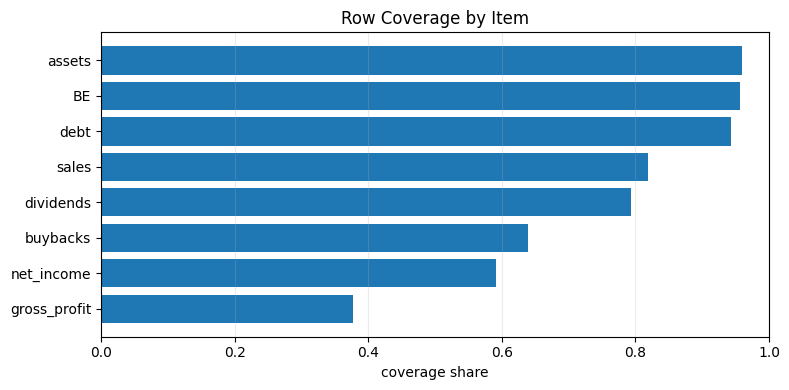

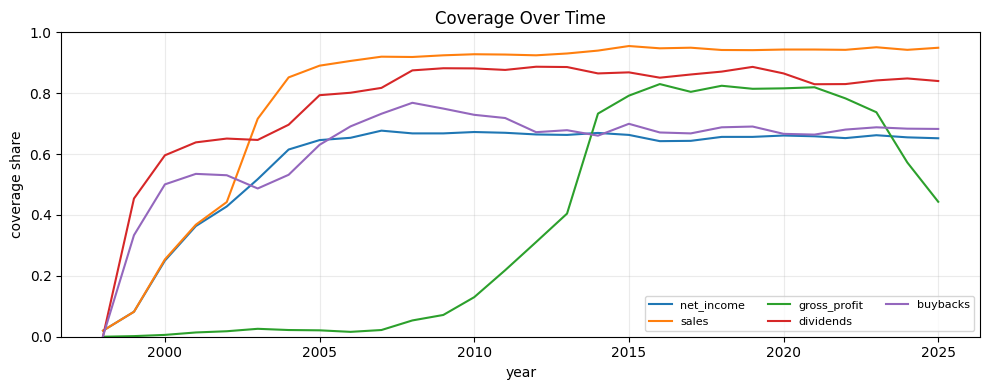

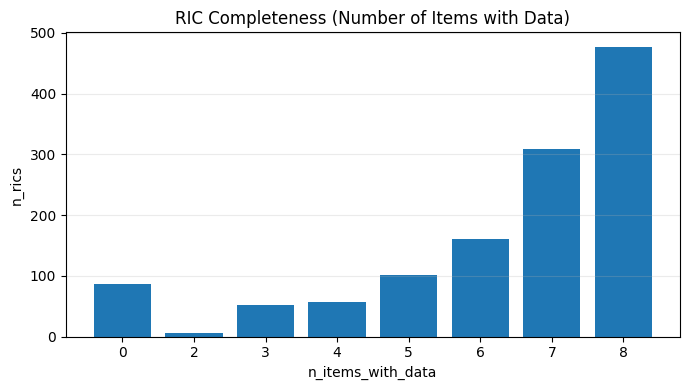

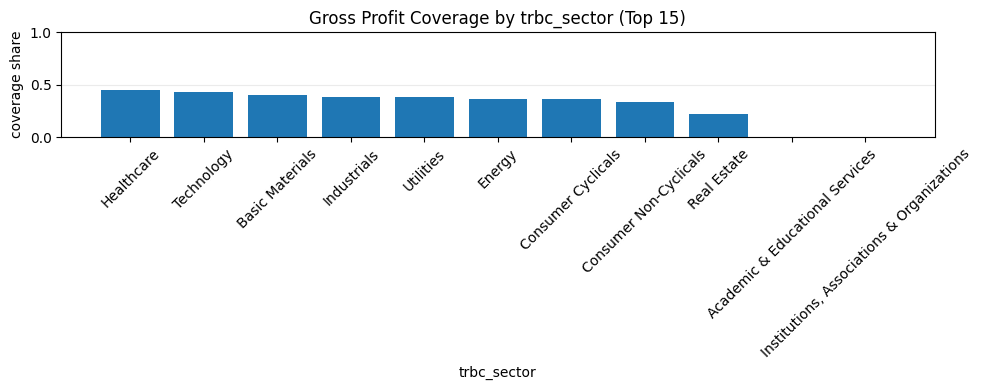


=== Alignment validation sample ===
File: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/netpayout_alignment_validation_sample.parquet
Rows: 300


,count,share
status,,
both_missing,150,0.50
model_has_value_snapshot_missing,75,0.25
match,75,0.25



=== ME check ===
ME column used: ME
RICs with NO ME at all: 0 / 1249 (0.0%)


In [20]:
# ============================================================
# Step 5B - Erweiterte Net-Payout Analyse
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

if not EURO500_NETPAYOUT_PATH.exists():
    raise FileNotFoundError(f"Missing file: {EURO500_NETPAYOUT_PATH}")

panel_step5 = pd.read_parquet(EURO500_NETPAYOUT_PATH).copy()

# Identify RIC column for grouping
ric_col = None
for c in ["pull_ric", "RIC_current", "RIC"]:
    if c in panel_step5.columns:
        ric_col = c
        break
if ric_col is None:
    raise KeyError("No RIC identifier found (expected one of: pull_ric, RIC_current, RIC)")

panel_step5[ric_col] = panel_step5[ric_col].astype("string").str.strip()
panel_step5.loc[panel_step5[ric_col] == "", ric_col] = pd.NA

if "asof_date" in panel_step5.columns:
    panel_step5["asof_date"] = pd.to_datetime(panel_step5["asof_date"], errors="coerce")

items = ["BE", "assets", "sales", "net_income", "gross_profit", "debt", "dividends", "buybacks"]
items = [c for c in items if c in panel_step5.columns]

for c in items:
    panel_step5[c] = pd.to_numeric(panel_step5[c], errors="coerce")

n_rows = len(panel_step5)
n_rics = int(panel_step5[ric_col].nunique(dropna=True))

print("=== Universe ===")
print(f"Rows: {n_rows}")
print(f"Unique RICs: {n_rics}")
print(f"Items analysed: {items}")

# ------------------------------------------------------------
# 1) Row-level and RIC-level coverage per item
# ------------------------------------------------------------
row_cov = {c: float(panel_step5[c].notna().mean()) for c in items}
ric_cov = {
    c: int(panel_step5.groupby(ric_col)[c].apply(lambda s: s.notna().any()).sum())
    for c in items
}

cov_df = pd.DataFrame({
    "row_coverage": pd.Series(row_cov),
    "n_RICs_with_at_least_one_value": pd.Series(ric_cov),
})
cov_df["ric_coverage"] = cov_df["n_RICs_with_at_least_one_value"] / n_rics if n_rics else np.nan
cov_df = cov_df.sort_values("row_coverage", ascending=False)

print("\n=== Item Coverage (row + RIC level) ===")
display(cov_df)

# Intersection: RICs with >=1 value in every item
if items:
    ric_has_item = panel_step5.groupby(ric_col)[items].apply(lambda df: df.notna().any())
    ric_has_all_items = ric_has_item.all(axis=1)
    n_all = int(ric_has_all_items.sum())

    print("\n=== Coverage Intersection ===")
    print(f"RICs with >=1 value for EVERY item: {n_all} ({(n_all/n_rics):.1%})" if n_rics else "No RICs")

# ------------------------------------------------------------
# 2) Time profile by year
# ------------------------------------------------------------
if "asof_date" in panel_step5.columns and panel_step5["asof_date"].notna().any():
    panel_step5["year"] = panel_step5["asof_date"].dt.year
    year_stats = panel_step5.groupby("year", as_index=False).agg(rows=(ric_col, "size"))
    for c in items:
        year_stats[f"cov_{c}"] = panel_step5.groupby("year")[c].apply(lambda s: s.notna().mean()).values

    print("\n=== Yearly Coverage (head) ===")
    display(year_stats.head(20))
    print("=== Yearly Coverage (tail) ===")
    display(year_stats.tail(20))

# ------------------------------------------------------------
# 3) RIC completeness distribution
# ------------------------------------------------------------
if items:
    ric_item_presence = panel_step5.groupby(ric_col)[items].apply(lambda df: df.notna().any())
    ric_item_presence["n_items_with_data"] = ric_item_presence.sum(axis=1)

    dist = (
        ric_item_presence["n_items_with_data"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("n_items_with_data")
        .to_frame("n_rics")
    )
    dist["share"] = dist["n_rics"] / n_rics if n_rics else np.nan

    print("\n=== RIC completeness distribution ===")
    display(dist)

# ------------------------------------------------------------
# 4) Problematic RICs (gross_profit)
# ------------------------------------------------------------
if "gross_profit" in items:
    gp_ric = panel_step5.groupby(ric_col)["gross_profit"].apply(lambda s: s.notna().mean()).sort_values()

    print("\n=== Lowest gross_profit coverage RICs (20) ===")
    display(gp_ric.head(20).rename("gross_profit_row_coverage").to_frame())

    print("=== Highest gross_profit coverage RICs (20) ===")
    display(gp_ric.tail(20).rename("gross_profit_row_coverage").to_frame())

# ------------------------------------------------------------
# 5) By sector / country (if columns exist)
# ------------------------------------------------------------
for grp_col in ["trbc_sector", "hq_country", "country_hq", "CountryHQ"]:
    if grp_col in panel_step5.columns:
        cols_for_grp = [c for c in ["sales", "net_income", "gross_profit", "dividends", "buybacks"] if c in items]
        if cols_for_grp:
            g = panel_step5.groupby(grp_col, dropna=False).agg(rows=(ric_col, "size"))
            for c in cols_for_grp:
                g[f"cov_{c}"] = panel_step5.groupby(grp_col, dropna=False)[c].apply(lambda s: s.notna().mean()).values
            g = g.sort_values("rows", ascending=False)

            print(f"\n=== Coverage by {grp_col} (top 20 by rows) ===")
            display(g.head(20))

# ------------------------------------------------------------
# 5A) Quick charts for faster diagnostics
# ------------------------------------------------------------
try:
    # Chart 1: item-level row coverage
    if not cov_df.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        cov_plot = cov_df.sort_values("row_coverage", ascending=True)
        ax.barh(cov_plot.index, cov_plot["row_coverage"])
        ax.set_title("Row Coverage by Item")
        ax.set_xlabel("coverage share")
        ax.set_xlim(0, 1)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

    # Chart 2: yearly coverage trend (core + payout/gp)
    if "year_stats" in locals() and not year_stats.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        for c in ["net_income", "sales", "gross_profit", "dividends", "buybacks"]:
            cc = f"cov_{c}"
            if cc in year_stats.columns:
                ax.plot(year_stats["year"], year_stats[cc], label=c)
        ax.set_title("Coverage Over Time")
        ax.set_xlabel("year")
        ax.set_ylabel("coverage share")
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.25)
        ax.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.show()

    # Chart 3: RIC completeness distribution
    if "dist" in locals() and not dist.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(dist.index.astype(str), dist["n_rics"], width=0.9)
        ax.set_title("RIC Completeness (Number of Items with Data)")
        ax.set_xlabel("n_items_with_data")
        ax.set_ylabel("n_rics")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

    # Chart 4: gross_profit coverage by sector (if available)
    for grp_col in ["trbc_sector", "hq_country", "country_hq", "CountryHQ"]:
        if grp_col in panel_step5.columns and "gross_profit" in items:
            ggp = (
                panel_step5.groupby(grp_col, dropna=False)["gross_profit"]
                .apply(lambda s: s.notna().mean())
                .sort_values(ascending=False)
                .head(15)
            )
            if len(ggp) > 0:
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.bar(ggp.index.astype(str), ggp.values, width=0.9)
                ax.set_title(f"Gross Profit Coverage by {grp_col} (Top 15)")
                ax.set_xlabel(grp_col)
                ax.set_ylabel("coverage share")
                ax.set_ylim(0, 1)
                ax.tick_params(axis="x", labelrotation=45)
                ax.grid(axis="y", alpha=0.25)
                plt.tight_layout()
                plt.show()
            break
except Exception as e:
    print(f"[WARN] plotting failed: {e}")

# ------------------------------------------------------------
# 6) Alignment validation sample (if available)
# ------------------------------------------------------------
val_path = DATA_DIR / "netpayout_alignment_validation_sample.parquet"
if val_path.exists():
    val = pd.read_parquet(val_path)
    print("\n=== Alignment validation sample ===")
    print(f"File: {val_path}")
    print(f"Rows: {len(val)}")

    if "status" in val.columns:
        status_df = val["status"].value_counts(dropna=False).rename_axis("status").to_frame("count")
        status_df["share"] = status_df["count"] / len(val) if len(val) else np.nan
        display(status_df)

        bad = val[val["status"].isin(["missing_but_snapshot_has_value", "mismatch"])]
        if not bad.empty:
            print("Potential alignment issues (sample of 30):")
            show_cols = [c for c in [ric_col, "pull_ric", "asof_date", "gross_profit", "snap_gross_profit", "status"] if c in bad.columns]
            display(bad[show_cols].head(30))
else:
    print("\n[INFO] No alignment validation sample found yet.")

# ------------------------------------------------------------
# 7) ME availability check
# ------------------------------------------------------------
me_candidates = [
    "ME",
    "market_equity",
    "MarketCap_EUR",
    "CompanyMarketCap_EUR",
    "market_cap_eur",
    "mcap_eur",
    "TR.MarketCap",
    "TR.CompanyMarketCap",
    "MarketCap",
    "CompanyMarketCap",
]
me_col = next((c for c in me_candidates if c in panel_step5.columns), None)

if me_col is None:
    print("\n[WARN] Kein ME-/MarketCap-Feld in euro500_netpayout gefunden. ME-Check uebersprungen.")
else:
    panel_step5[me_col] = pd.to_numeric(panel_step5[me_col], errors="coerce")
    ric_has_me = panel_step5.groupby(ric_col)[me_col].apply(lambda s: s.notna().any())
    rics_no_me = ric_has_me[ric_has_me == False].index.tolist()

    print("\n=== ME check ===")
    print(f"ME column used: {me_col}")
    print(f"RICs with NO ME at all: {len(rics_no_me)} / {n_rics} ({(len(rics_no_me)/n_rics):.1%})" if n_rics else "No RICs")

    if len(rics_no_me) > 0:
        display(pd.DataFrame({ric_col: rics_no_me}).head(30))




